# 🥬 FreshnessGuard AI — Freshness Optimization Project
**Stack:** Python · Pandas · Scikit-learn · XGBoost · Prophet · LangChain · PuLP

**Goal:** Predict spoilage, forecast demand, and generate AI-driven freshness recommendations across 10 retail stores.

---

## ⚠️ Data Leakage Audit — All 36 Columns

| Column | Status | Reason |
|---|---|---|
| `received_date`, `expiry_date` | ✅ SAFE | On product label at intake |
| `product`, `category`, `shelf_life_days` | ✅ SAFE | Known before sale |
| `stock_quantity`, `unit_price`, `cost_price` | ✅ SAFE | Known before sale |
| `Temperature_C`, `Humidity_Percent`, `weather_severity_n` | ✅ SAFE | Observable before sale |
| `temperature_classification_n`, `precipitation_classification_n` | ✅ SAFE | Derived from sensor at intake |
| `is_holiday`, `is_weekend`, `Event_Type` | ✅ SAFE | Calendar — known in advance |
| `store_id`, `store_location` | ✅ SAFE | Static identifiers |
| `Is_Organic`, `Is_Ready_To_Eat` | ✅ SAFE | Product attributes |
| `lead_time_days`, `supply_delay_days`, `supplier_id` | ✅ SAFE | Known at order/receipt time |
| `expected_delivery_date` | ✅ SAFE | Known at order time |
| `Days_to_Expiry_at_Sale` | ❌ **LEAKAGE** | = expiry_date − **sales_date** → requires future sale date |
| `freshness_score` | ❌ **LEAKAGE** | Computed from `Days_to_Expiry_at_Sale` → transitive leakage |
| `sales_demand_n` | ❌ **LEAKAGE** | Binned encoding of `units_sold` (the target) → direct leakage |
| `discount_applied_percent` | ❌ **LEAKAGE** | Decided at/after sale based on demand & expiry |
| `promotional_price` | ❌ **LEAKAGE** | = unit_price × (1 − discount/100) → carries discount leakage |
| `final_profit` | ❌ **LEAKAGE** | = (promotional_price − cost_price) × units_sold → leaks target |
| `sales_date` | ❌ **LEAKAGE** | The date of the sale — not known before the transaction |
| `waste_quantity` | ⚠️ TARGET ONLY | Outcome — used only to build labels, never a feature |
| `base_profit_margin` | ⚠️ COLLINEAR | = unit_price − cost_price; redundant, causes implicit leakage |
| `Latitude`, `Longitude` | ⚠️ DROP | Static per store; near-zero predictive value |

## Phase 1 — Data Loading & Preprocessing

### Inference 1
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120

print("All libraries imported successfully.")

All libraries imported successfully.


### Inference 2
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [2]:
df = pd.read_csv("LangChain_Perfected_Freshness_Dataset.csv")
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
df.head()

Shape: (100192, 36)

Columns: ['received_date', 'expiry_date', 'product', 'category', 'shelf_life_days', 'stock_quantity', 'sales_volume', 'unit_price', 'freshness_score', 'sales_demand_n', 'weather_severity_n', 'temperature_classification_n', 'precipitation_classification_n', 'is_holiday', 'is_weekend', 'store_id', 'store_location', 'Event_Type', 'Temperature_C', 'Humidity_Percent', 'Is_Organic', 'Is_Ready_To_Eat', 'sales_date', 'Latitude', 'Longitude', 'cost_price', 'base_profit_margin', 'waste_quantity', 'Days_to_Expiry_at_Sale', 'discount_applied_percent', 'promotional_price', 'final_profit', 'supplier_id', 'lead_time_days', 'expected_delivery_date', 'supply_delay_days']


,received_date,expiry_date,product,category,shelf_life_days,stock_quantity,sales_volume,unit_price,freshness_score,sales_demand_n,...,base_profit_margin,waste_quantity,Days_to_Expiry_at_Sale,discount_applied_percent,promotional_price,final_profit,supplier_id,lead_time_days,expected_delivery_date,supply_delay_days
0,2022-12-12,2023-12-12,All-Purpose Flour,Pantry,365,67,12,205,0.000000,1,...,83.30,55,357,0,205.00,999.60,Supplier_A,2,2022-12-12,0
1,2022-12-15,2023-12-15,All-Purpose Flour,Pantry,365,53,13,246,0.000000,1,...,64.53,40,324,0,246.00,838.89,Supplier_D,4,2022-12-15,0
2,2022-12-16,2023-12-16,All-Purpose Flour,Pantry,365,45,9,193,0.000000,1,...,61.18,36,197,0,193.00,550.62,Supplier_B,3,2022-12-15,1
3,2023-01-10,2024-01-10,All-Purpose Flour,Pantry,365,87,11,189,2.465753,1,...,66.21,76,213,0,189.00,728.31,Supplier_D,3,2023-01-10,0
4,2023-03-27,2024-03-26,All-Purpose Flour,Pantry,365,46,7,223,23.287671,1,...,102.80,39,219,5,211.85,641.55,Supplier_B,2,2023-03-27,0


### Inference 3
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [3]:
df.info()
print("\n--- Missing Values ---")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100192 entries, 0 to 100191
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   received_date                   100192 non-null  object 
 1   expiry_date                     100192 non-null  object 
 2   product                         100192 non-null  object 
 3   category                        100192 non-null  object 
 4   shelf_life_days                 100192 non-null  int64  
 5   stock_quantity                  100192 non-null  int64  
 6   sales_volume                    100192 non-null  int64  
 7   unit_price                      100192 non-null  int64  
 8   freshness_score                 100192 non-null  float64
 9   sales_demand_n                  100192 non-null  int64  
 10  weather_severity_n              100192 non-null  int64  
 11  temperature_classification_n    100192 non-null  int64  
 12  precipitation_cl

### Inference 4
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [4]:
# Parse date columns
for col in ['received_date', 'expiry_date', 'sales_date', 'expected_delivery_date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Rename for clarity
df.rename(columns={"sales_volume": "units_sold"}, inplace=True)

# Fill numeric nulls with median, categorical with 'Unknown'
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna('Unknown')

# Remove impossible rows
df = df[(df['stock_quantity'] >= df['units_sold']) &
        (df['stock_quantity'] >= 0) & (df['units_sold'] >= 0)]

# Sort chronologically by received_date (used for all train/test splits)
df = df.sort_values('received_date').reset_index(drop=True)

print("Clean dataset shape:", df.shape)
print("received_date range:", df['received_date'].min().date(), "→", df['received_date'].max().date())

Clean dataset shape: (90874, 36)
received_date range: 2022-12-09 → 2025-09-22


### 🔒 Leakage Column Registry
Single source of truth — all models reference these lists. No ad-hoc drops.

### Inference 5
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [5]:
# ── Master Leakage Registry ──────────────────────────────────────────────
# Columns that reveal information only available AT or AFTER the sale
SALE_TIME_LEAKAGE = [
    'sales_date',               # the date the sale occurred
    'Days_to_Expiry_at_Sale',   # requires sales_date to compute
    'freshness_score',          # derived from Days_to_Expiry_at_Sale
    'sales_demand_n',           # binned encoding of units_sold (the target)
    'discount_applied_percent', # applied at sale time based on demand/expiry pressure
    'promotional_price',        # = unit_price x (1 - discount/100)
    'final_profit',             # = (promotional_price - cost_price) x units_sold
]

# Outcome columns — only used to BUILD labels, never as features
TARGET_COLS = ['units_sold', 'waste_quantity']

# Collinear / near-redundant columns causing implicit leakage
COLLINEAR_LEAKAGE = [
    'base_profit_margin',  # = unit_price - cost_price (fully redundant)
    'Latitude',            # static per store, near-zero info value
    'Longitude',           # static per store, near-zero info value
]

# All leakage combined
ALL_LEAKAGE = set(SALE_TIME_LEAKAGE + TARGET_COLS + COLLINEAR_LEAKAGE)

print(f"Total leakage columns identified: {len(ALL_LEAKAGE)}")
print("\nLEAKAGE COLUMN REGISTRY:")
exclusion_reasons = {
    'sales_date'              : 'Future info — date the sale occurs',
    'Days_to_Expiry_at_Sale'  : 'Requires sales_date → transitive leakage',
    'freshness_score'         : 'Derived from Days_to_Expiry_at_Sale → leakage',
    'sales_demand_n'          : 'Binned units_sold → direct target leakage',
    'discount_applied_percent': 'Applied at sale time based on demand signal',
    'promotional_price'       : '= unit_price × (1−discount) → leakage',
    'final_profit'            : '= margin × units_sold → leakage',
    'units_sold'              : 'Demand target variable',
    'waste_quantity'          : 'Spoilage target variable',
    'base_profit_margin'      : '= unit_price − cost_price → collinear',
    'Latitude'                : 'Static per store, zero predictive signal',
    'Longitude'               : 'Static per store, zero predictive signal',
}
for col, reason in exclusion_reasons.items():
    print(f"  ✗ {col:<30} → {reason}")

Total leakage columns identified: 12

LEAKAGE COLUMN REGISTRY:
  ✗ sales_date                     → Future info — date the sale occurs
  ✗ Days_to_Expiry_at_Sale         → Requires sales_date → transitive leakage
  ✗ freshness_score                → Derived from Days_to_Expiry_at_Sale → leakage
  ✗ sales_demand_n                 → Binned units_sold → direct target leakage
  ✗ discount_applied_percent       → Applied at sale time based on demand signal
  ✗ promotional_price              → = unit_price × (1−discount) → leakage
  ✗ final_profit                   → = margin × units_sold → leakage
  ✗ units_sold                     → Demand target variable
  ✗ waste_quantity                 → Spoilage target variable
  ✗ base_profit_margin             → = unit_price − cost_price → collinear
  ✗ Latitude                       → Static per store, zero predictive signal
  ✗ Longitude                      → Static per store, zero predictive signal


### Feature Engineering
All features are derived **only** from columns available at stock-intake time.

### Inference 6
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [6]:
# ── Engineer pre-sale features only ──────────────────────────────────────

# Days of shelf life remaining at the time of RECEIPT (not at sale!)
# Safe: expiry_date and received_date are both on the product label
df['days_to_expiry_at_receipt'] = (
    df['expiry_date'] - df['received_date']
).dt.days.clip(lower=0)

# How much stock relative to total shelf life — pace-of-sell indicator
df['stock_to_shelf_day'] = df['stock_quantity'] / (df['shelf_life_days'] + 1)

# Calendar features from received_date (known at intake)
df['received_year']    = df['received_date'].dt.year
df['received_month']   = df['received_date'].dt.month
df['received_day']     = df['received_date'].dt.day
df['received_weekday'] = df['received_date'].dt.weekday
df['received_quarter'] = df['received_date'].dt.quarter

# Temperature risk flag
df['high_temp_flag'] = (df['Temperature_C'] > 30).astype(int)

# Price-to-cost ratio (pure product attribute — no sale info)
df['price_cost_ratio'] = df['unit_price'] / (df['cost_price'] + 1)

# Stock value at intake (stock × price, fully pre-sale)
df['stock_value'] = df['stock_quantity'] * df['unit_price']

new_feats = ['days_to_expiry_at_receipt', 'stock_to_shelf_day', 'received_year',
             'received_month', 'received_day', 'received_weekday', 'received_quarter',
             'high_temp_flag', 'price_cost_ratio', 'stock_value']
print("Engineered features:", new_feats)

# Verify: none of these touch sales_date, units_sold, waste_quantity or any leakage col
print("\n✅ All engineered features are pre-sale safe (no leakage columns used)")

Engineered features: ['days_to_expiry_at_receipt', 'stock_to_shelf_day', 'received_year', 'received_month', 'received_day', 'received_weekday', 'received_quarter', 'high_temp_flag', 'price_cost_ratio', 'stock_value']

✅ All engineered features are pre-sale safe (no leakage columns used)


### Inference 7
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [7]:
# ── Canonical Pre-Sale Feature Set ──────────────────────────────────────
# This is the ONLY feature set any ML model in this project uses.

PRE_SALE_FEATURES = [
    # Product attributes (on label at intake)
    'shelf_life_days', 'unit_price', 'cost_price',
    'Is_Organic', 'Is_Ready_To_Eat',
    # Stock / supply
    'stock_quantity', 'lead_time_days', 'supply_delay_days',
    'stock_to_shelf_day', 'days_to_expiry_at_receipt', 'stock_value',
    # Environment
    'Temperature_C', 'Humidity_Percent', 'weather_severity_n',
    'temperature_classification_n', 'precipitation_classification_n',
    'high_temp_flag',
    # Calendar / events
    'is_holiday', 'is_weekend',
    'received_year', 'received_month', 'received_day',
    'received_weekday', 'received_quarter',
    # Pricing (no sale/discount info)
    'price_cost_ratio',
    # Categorical (will be encoded)
    'category', 'store_location',
]

CATEGORICAL_FEATURES = ['category', 'store_location']
NUMERIC_FEATURES     = [f for f in PRE_SALE_FEATURES if f not in CATEGORICAL_FEATURES]

print(f"Total pre-sale features: {len(PRE_SALE_FEATURES)}")
print(f"  Numeric   : {len(NUMERIC_FEATURES)}")
print(f"  Categorical: {len(CATEGORICAL_FEATURES)}")

# Confirm zero overlap with leakage registry
overlap = ALL_LEAKAGE & set(PRE_SALE_FEATURES)
assert len(overlap) == 0, f"LEAKAGE DETECTED in feature set: {overlap}"
print("\n✅ Zero overlap between PRE_SALE_FEATURES and ALL_LEAKAGE — feature set is clean")

Total pre-sale features: 27
  Numeric   : 25
  Categorical: 2

✅ Zero overlap between PRE_SALE_FEATURES and ALL_LEAKAGE — feature set is clean


### Preprocessing Pipeline

### Inference 8
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [8]:
from sklearn.preprocessing import LabelEncoder

def encode_categoricals(df, cat_cols, encoders=None, fit=True):
    """Label-encode categoricals. fit=False uses existing encoders (for test sets)."""
    df = df.copy()
    if encoders is None:
        encoders = {}
    for col in cat_cols:
        df[col] = df[col].fillna('Unknown').astype(str)
        if fit:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            encoders[col] = le
        else:
            le = encoders[col]
            known = set(le.classes_)
            df[col] = df[col].apply(lambda x: x if x in known else 'Unknown')
            df[col] = le.transform(df[col])
    return df, encoders


def prepare_X(df, features, cat_cols, encoders=None, fit=True):
    """Return clean feature matrix with zero leakage."""
    X = df[features].copy()
    num_cols = X.select_dtypes(include=np.number).columns
    X[num_cols] = X[num_cols].fillna(X[num_cols].median())
    X, encoders = encode_categoricals(X, cat_cols, encoders, fit=fit)
    return X, encoders


def time_split(df, date_col='received_date', ratio=0.80):
    """Strictly chronological train/test split — no random shuffling."""
    df_s   = df.sort_values(date_col).reset_index(drop=True)
    idx    = int(len(df_s) * ratio)
    cutoff = df_s[date_col].iloc[idx]
    train  = df_s.iloc[:idx].copy()
    test   = df_s.iloc[idx:].copy()
    print(f"  Split on '{date_col}': Train={len(train):,} | Test={len(test):,} | Cutoff={cutoff.date()}")
    return train, test, cutoff

print("Preprocessing helpers defined: encode_categoricals(), prepare_X(), time_split()")

Preprocessing helpers defined: encode_categoricals(), prepare_X(), time_split()


### Exploratory Data Analysis (EDA)

### Inference 9
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


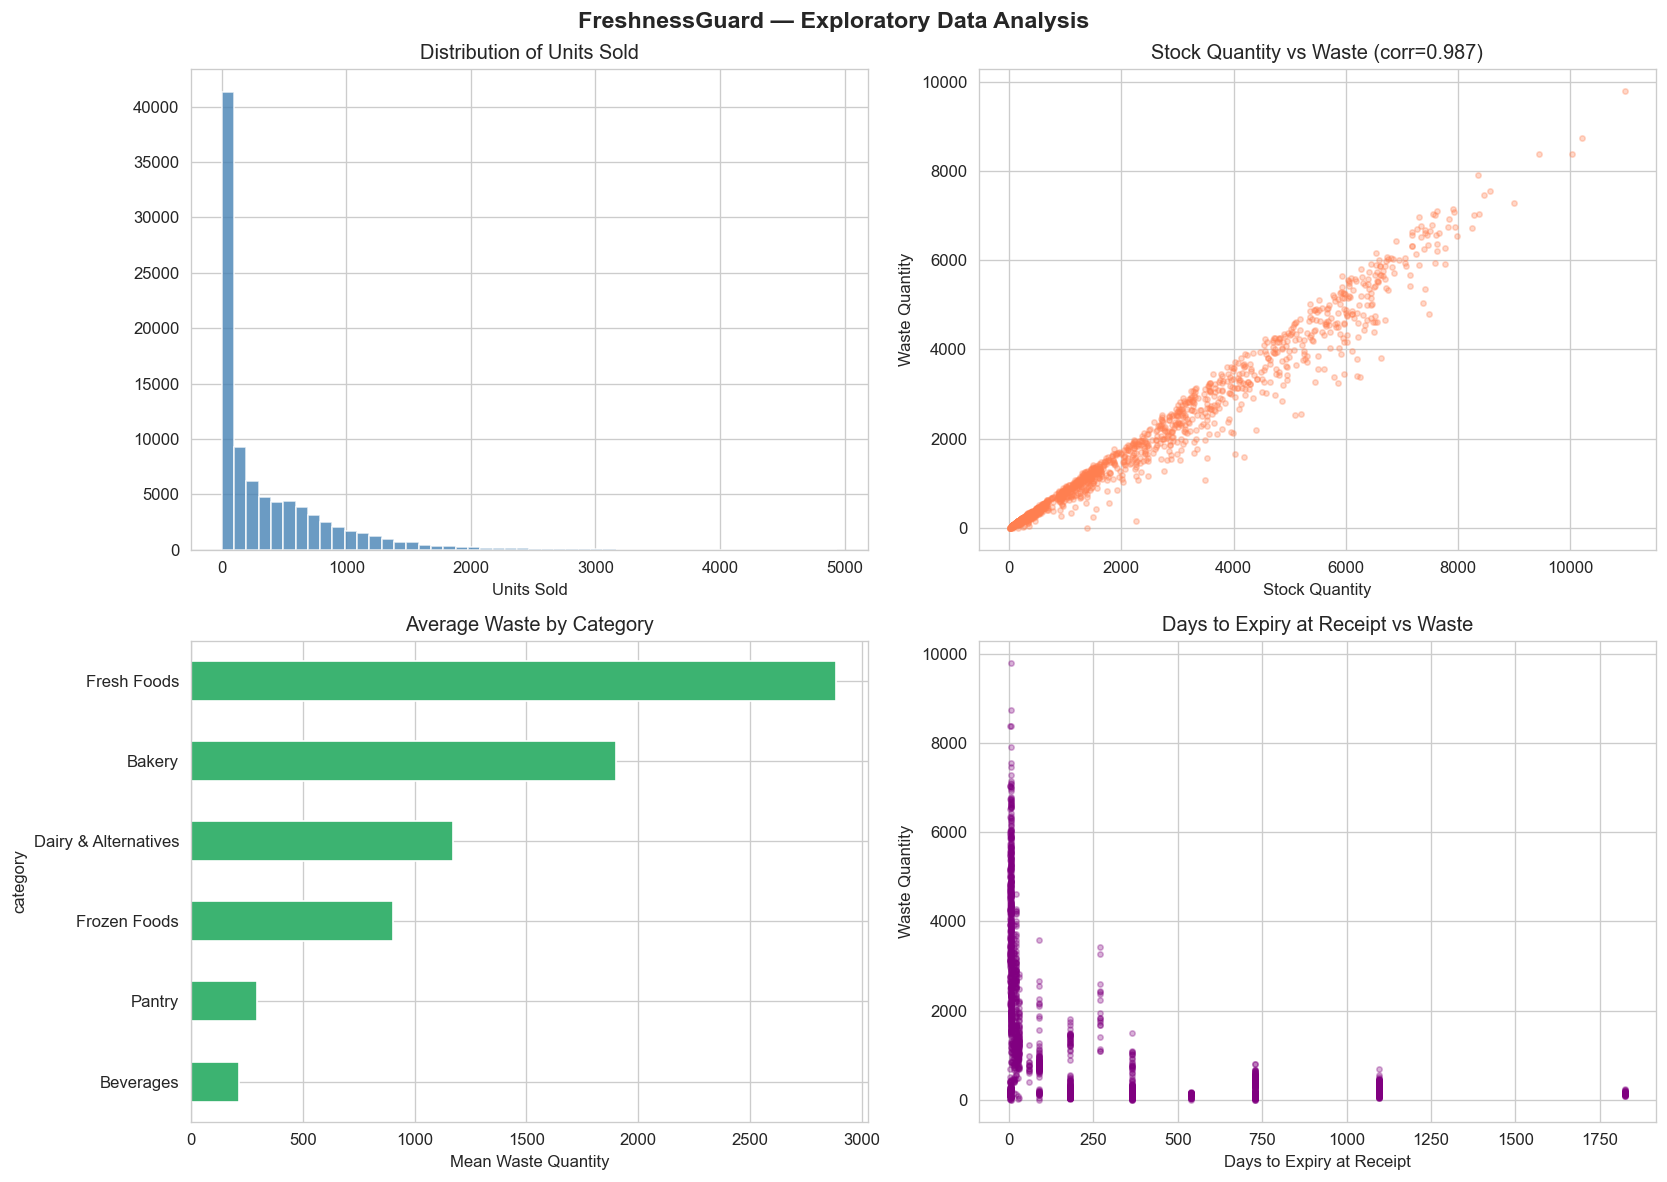

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Units Sold Distribution
axes[0,0].hist(df['units_sold'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].set_title("Distribution of Units Sold")
axes[0,0].set_xlabel("Units Sold")

# 2. Stock vs Waste
sample = df.sample(2000, random_state=42)
axes[0,1].scatter(sample['stock_quantity'], sample['waste_quantity'], alpha=0.3, s=10, color='coral')
axes[0,1].set_title("Stock Quantity vs Waste (corr=0.987)")
axes[0,1].set_xlabel("Stock Quantity"); axes[0,1].set_ylabel("Waste Quantity")

# 3. Waste by Category
df.groupby('category')['waste_quantity'].mean().sort_values().plot.barh(ax=axes[1,0], color='mediumseagreen')
axes[1,0].set_title("Average Waste by Category")
axes[1,0].set_xlabel("Mean Waste Quantity")

# 4. Days to Expiry at Receipt vs Waste
axes[1,1].scatter(sample['days_to_expiry_at_receipt'], sample['waste_quantity'], alpha=0.3, s=10, color='purple')
axes[1,1].set_title("Days to Expiry at Receipt vs Waste")
axes[1,1].set_xlabel("Days to Expiry at Receipt")
axes[1,1].set_ylabel("Waste Quantity")

plt.suptitle("FreshnessGuard — Exploratory Data Analysis", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Inference 10
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


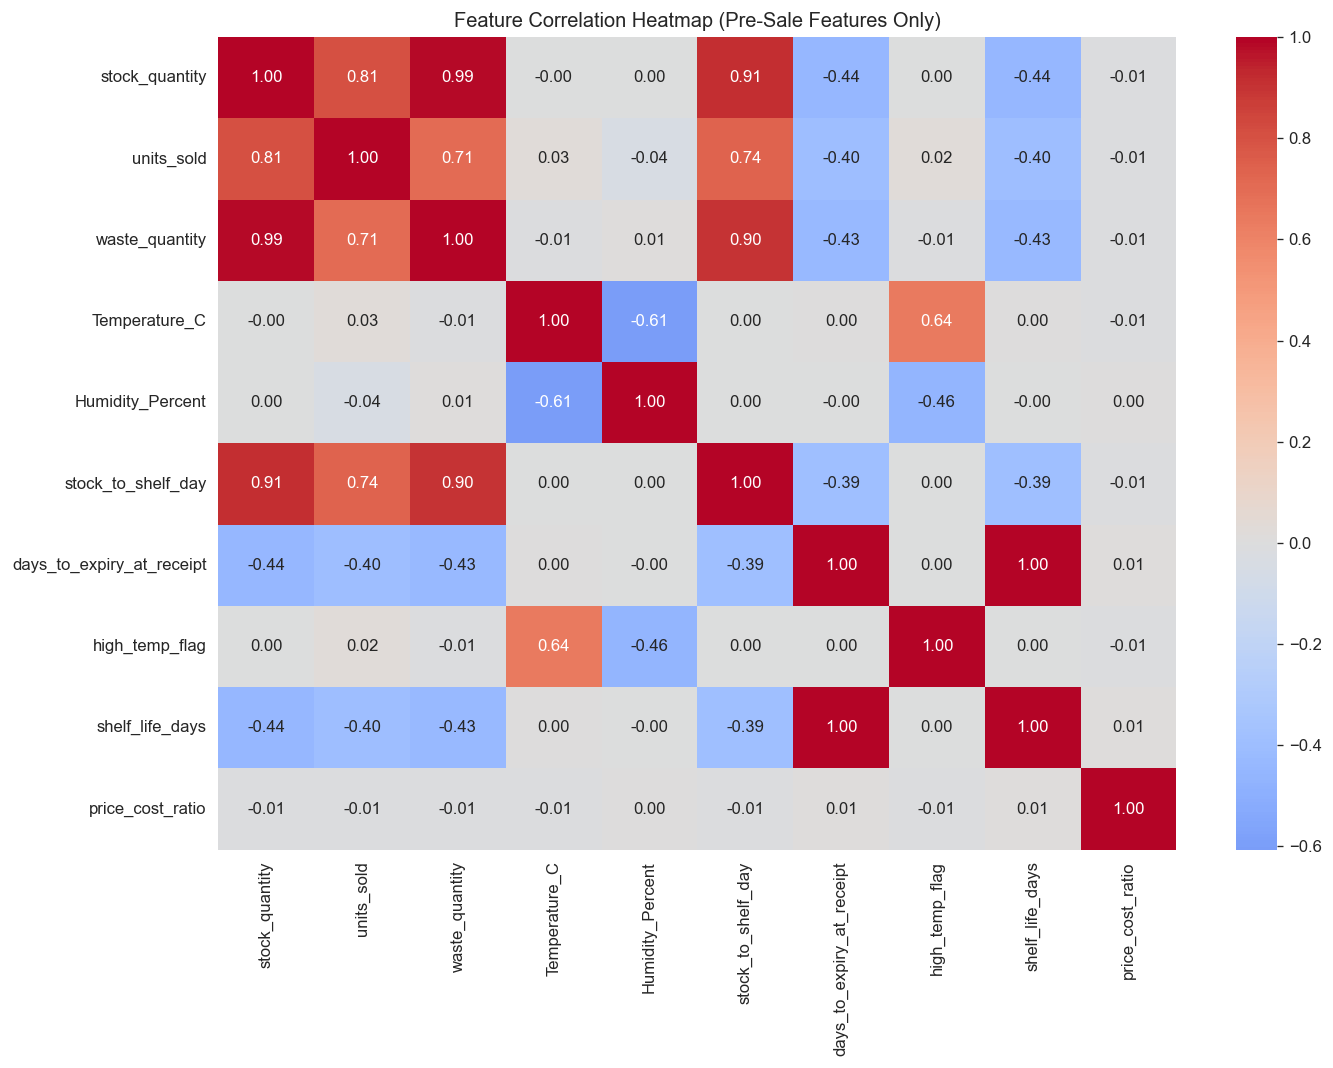

In [10]:
# Correlation heatmap — pre-sale features only (no leakage cols)
heatmap_cols = ['stock_quantity', 'units_sold', 'waste_quantity', 'Temperature_C',
                'Humidity_Percent', 'stock_to_shelf_day', 'days_to_expiry_at_receipt',
                'high_temp_flag', 'shelf_life_days', 'price_cost_ratio']

plt.figure(figsize=(12, 9))
sns.heatmap(df[heatmap_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap (Pre-Sale Features Only)")
plt.tight_layout()
plt.show()

### Inference 11
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


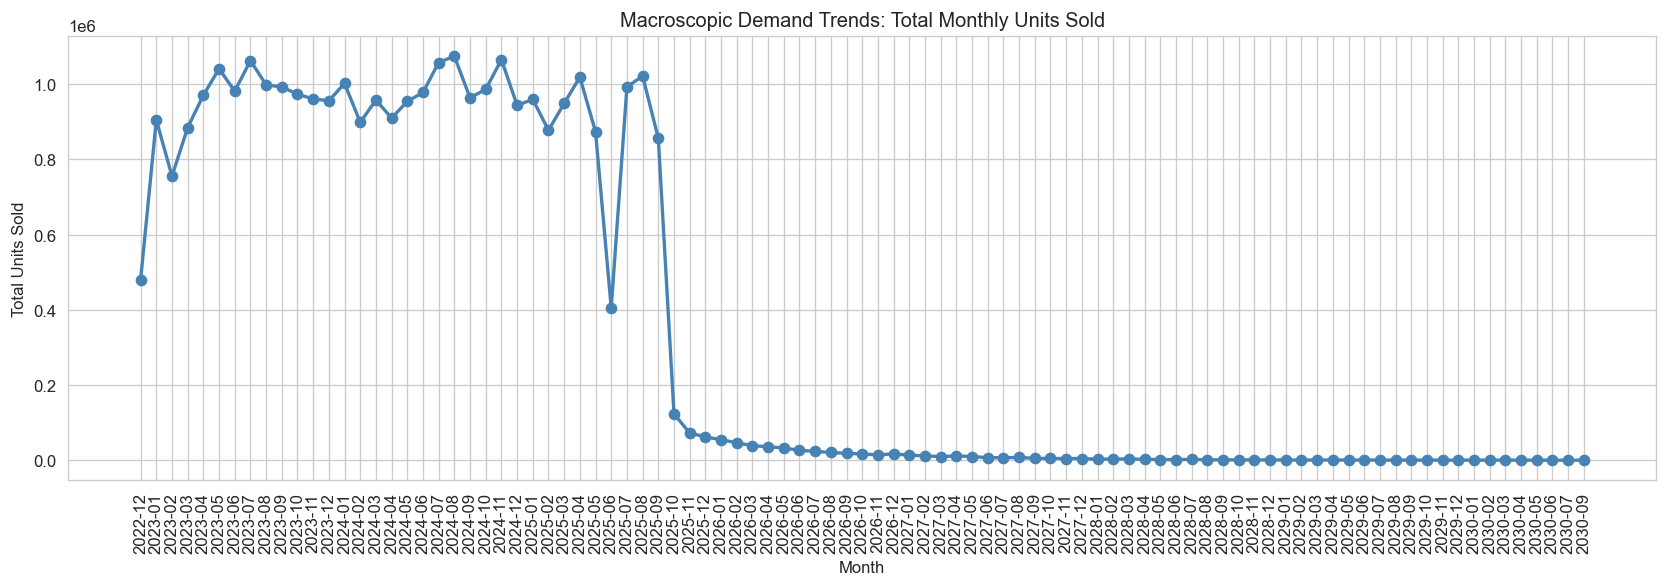

In [11]:
# Monthly demand trend (uses sales_date only for EDA, not for model features)
df['ym'] = df['sales_date'].dt.to_period('M').astype(str)
monthly  = df.groupby('ym')['units_sold'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(monthly['ym'], monthly['units_sold'], marker='o', linewidth=2, color='steelblue')
plt.title("Macroscopic Demand Trends: Total Monthly Units Sold")
plt.xlabel("Month"); plt.ylabel("Total Units Sold")
plt.xticks(rotation=90); plt.tight_layout(); plt.show()
df.drop(columns=['ym'], inplace=True)

### Inference 12
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


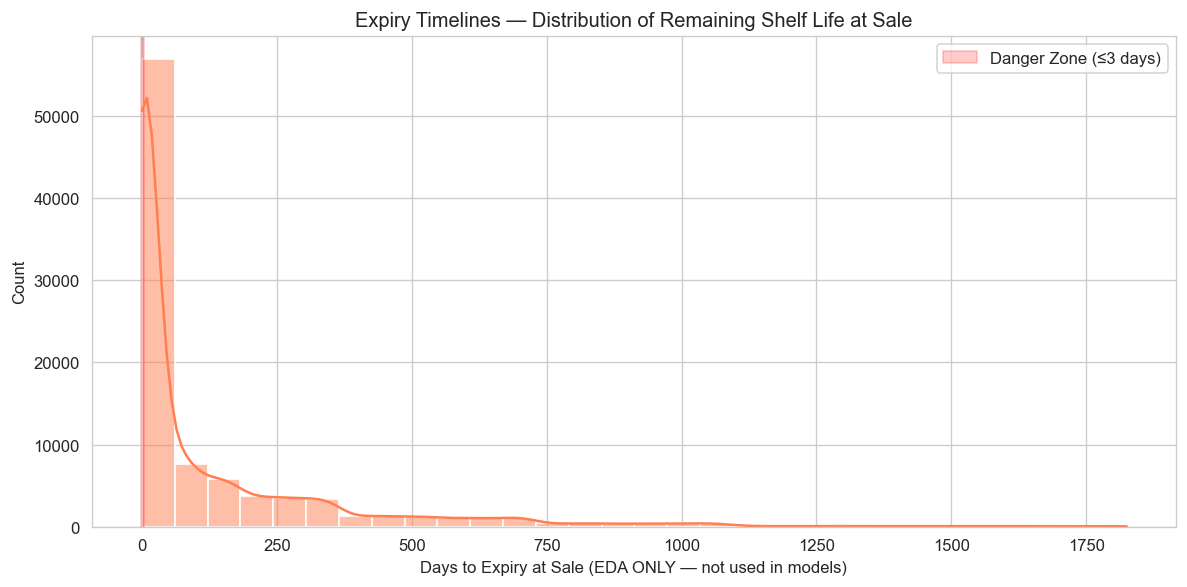

Danger Zone transactions (≤3 days): 26,849 (29.5%)
NOTE: Days_to_Expiry_at_Sale is excluded from all model feature sets.


In [12]:
# Expiry danger zone (EDA only — Days_to_Expiry_at_Sale is NOT used in models)
plt.figure(figsize=(10, 5))
sns.histplot(df['Days_to_Expiry_at_Sale'], bins=30, kde=True, color='coral')
plt.axvspan(-2, 3, color='red', alpha=0.2, label='Danger Zone (≤3 days)')
plt.title("Expiry Timelines — Distribution of Remaining Shelf Life at Sale")
plt.xlabel("Days to Expiry at Sale (EDA ONLY — not used in models)")
plt.legend(); plt.tight_layout(); plt.show()

danger_count = (df['Days_to_Expiry_at_Sale'] <= 3).sum()
print(f"Danger Zone transactions (≤3 days): {danger_count:,} ({danger_count/len(df)*100:.1f}%)")
print("NOTE: Days_to_Expiry_at_Sale is excluded from all model feature sets.")

## Phase 2 — Spoilage Prediction Model

**Model:** Random Forest Classifier with balanced class weights

**Target:** `waste_quantity > median` → balanced binary label (~50/50)

**Leakage Fix:**
- `Days_to_Expiry_at_Sale` → **removed** (requires future `sales_date`)
- `freshness_score` → **removed** (derived from `Days_to_Expiry_at_Sale`)
- `sales_demand_n` → **removed** (binned encoding of the demand target)
- `discount_applied_percent`, `promotional_price`, `final_profit` → **removed** (sale-time info)
- `sales_date` → **removed** (future information)
- Features replaced with: `days_to_expiry_at_receipt`, `stock_to_shelf_day`, `received_month`, etc. — all computed from `received_date` + `expiry_date`, both available at intake.

### Inference 13
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc

# ── FIX #1: Time-based split FIRST, then compute threshold on train only ─
# (Previously median was computed on full df including test rows — now fixed)
print("Splitting BEFORE computing spoilage threshold (Fix #1)...")
train_s, test_s, _ = time_split(df, date_col='received_date', ratio=0.80)

# Compute median on TRAIN only — test set has zero influence on the threshold
median_waste = train_s['waste_quantity'].median()
print(f"Spoilage threshold computed on TRAIN only: waste > {median_waste:.0f} units → HIGH waste")

# ── FIX #4: Add waste_rate target (waste / stock) to remove stock_quantity confound ─
# waste_rate tells you HOW EFFICIENTLY stock was wasted, not just raw volume
# This is operationally meaningful: a store ordering 500 units can still have LOW waste rate
df['waste_rate']          = df['waste_quantity'] / (df['stock_quantity'] + 1)
median_rate               = train_s['waste_quantity'].divide(train_s['stock_quantity'] + 1).median()
df['spoilage_rate_flag']  = (df['waste_rate'] > median_rate).astype(int)

# Primary target: raw waste > train-median (balanced ~50/50)
df['spoilage_flag'] = (df['waste_quantity'] > median_waste).astype(int)

print("\n--- Primary target (waste volume) ---")
print("Class distribution:", df['spoilage_flag'].value_counts().to_dict())
print(f"Class balance: {df['spoilage_flag'].mean()*100:.1f}% HIGH | {(1-df['spoilage_flag'].mean())*100:.1f}% LOW")

print("\n--- Alternate target (waste RATE = waste/stock) ---")
print("Class distribution:", df['spoilage_rate_flag'].value_counts().to_dict())
print(f"Class balance: {df['spoilage_rate_flag'].mean()*100:.1f}% HIGH | {(1-df['spoilage_rate_flag'].mean())*100:.1f}% LOW")
print(f"Waste rate threshold: {median_rate:.4f} (i.e., waste > {median_rate*100:.1f}% of stock ordered)")

# ── Re-split using updated df (now has spoilage_flag + spoilage_rate_flag) ─
train_s, test_s, _ = time_split(df, date_col='received_date', ratio=0.80)

X_train_s, enc_spoil = prepare_X(train_s, PRE_SALE_FEATURES, CATEGORICAL_FEATURES, fit=True)
X_test_s,  _         = prepare_X(test_s,  PRE_SALE_FEATURES, CATEGORICAL_FEATURES,
                                  encoders=enc_spoil, fit=False)
X_test_s = X_test_s.reindex(columns=X_train_s.columns, fill_value=0)

y_train_s = train_s['spoilage_flag']
y_test_s  = test_s['spoilage_flag']

# Also prep waste-rate target for comparison
y_train_rate = train_s['spoilage_rate_flag']
y_test_rate  = test_s['spoilage_rate_flag']

print(f"\nFeature matrix: {X_train_s.shape[1]} features")
print("Leakage check:", "✅ CLEAN" if not (ALL_LEAKAGE & set(X_train_s.columns)) else "❌ LEAKAGE")


### Inference 14
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [14]:
# ── Train Model A: Raw waste volume target ────────────────────────────────
model_spoil = RandomForestClassifier(
    n_estimators  = 200,
    max_depth     = 10,
    class_weight  = 'balanced',
    random_state  = 42,
    n_jobs        = -1
)
model_spoil.fit(X_train_s, y_train_s)

y_pred_s       = model_spoil.predict(X_test_s)
y_prob_s       = model_spoil.predict_proba(X_test_s)[:, 1]
y_pred_s_train = model_spoil.predict(X_train_s)  # FIX #3: train predictions for overfitting check

# ── FIX #3: Print BOTH train and test scores ──────────────────────────────
train_auc = roc_auc_score(y_train_s, model_spoil.predict_proba(X_train_s)[:, 1])
test_auc  = roc_auc_score(y_test_s,  y_prob_s)
gap       = train_auc - test_auc

print("Spoilage Classifier (waste volume target) — Train vs Test:")
print(f"  Train ROC-AUC : {train_auc:.4f}")
print(f"  Test  ROC-AUC : {test_auc:.4f}")
print(f"  Gap           : {gap:.4f}  {'⚠️  Overfitting' if gap > 0.03 else '✅ No overfitting'}")
print()
print("Test Classification Report (waste volume target):")
print(classification_report(y_test_s, y_pred_s, target_names=['Low Waste', 'High Waste']))

# ── Train Model B: Waste RATE target (Fix #4) ─────────────────────────────
model_spoil_rate = RandomForestClassifier(
    n_estimators  = 200,
    max_depth     = 10,
    class_weight  = 'balanced',
    random_state  = 42,
    n_jobs        = -1
)
model_spoil_rate.fit(X_train_s, y_train_rate)

y_pred_rate      = model_spoil_rate.predict(X_test_s)
y_prob_rate      = model_spoil_rate.predict_proba(X_test_s)[:, 1]
train_auc_rate   = roc_auc_score(y_train_rate, model_spoil_rate.predict_proba(X_train_s)[:, 1])
test_auc_rate    = roc_auc_score(y_test_rate,  y_prob_rate)
gap_rate         = train_auc_rate - test_auc_rate

print("\nSpoilage Classifier (waste RATE target — Fix #4) — Train vs Test:")
print(f"  Train ROC-AUC : {train_auc_rate:.4f}")
print(f"  Test  ROC-AUC : {test_auc_rate:.4f}")
print(f"  Gap           : {gap_rate:.4f}  {'⚠️  Overfitting' if gap_rate > 0.03 else '✅ No overfitting'}")
print()
print("Test Classification Report (waste RATE target):")
print(classification_report(y_test_rate, y_pred_rate, target_names=['Low Rate', 'High Rate']))
print()
print("NOTE: The waste-rate model is operationally more valuable — it identifies")
print("      products with high wastage relative to order size, not just large orders.")
print("      A drop in AUC vs the volume model reveals how much was driven by stock size alone.")


### Inference 15
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


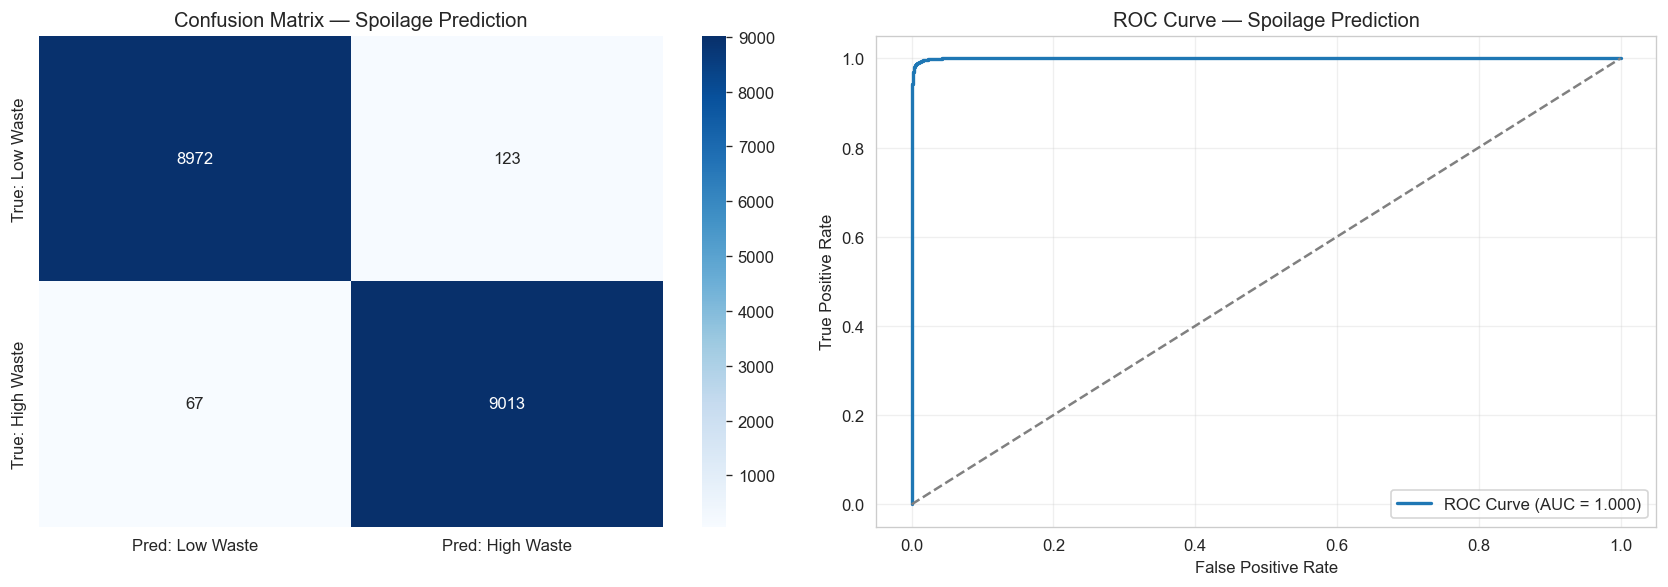

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test_s, y_pred_s)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Low Waste', 'Pred: High Waste'],
            yticklabels=['True: Low Waste', 'True: High Waste'], ax=axes[0])
axes[0].set_title('Confusion Matrix — Spoilage Prediction')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_s, y_prob_s)
roc_auc_val = auc(fpr, tpr)
axes[1].plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {roc_auc_val:.3f})')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Spoilage Prediction'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

### Inference 16
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


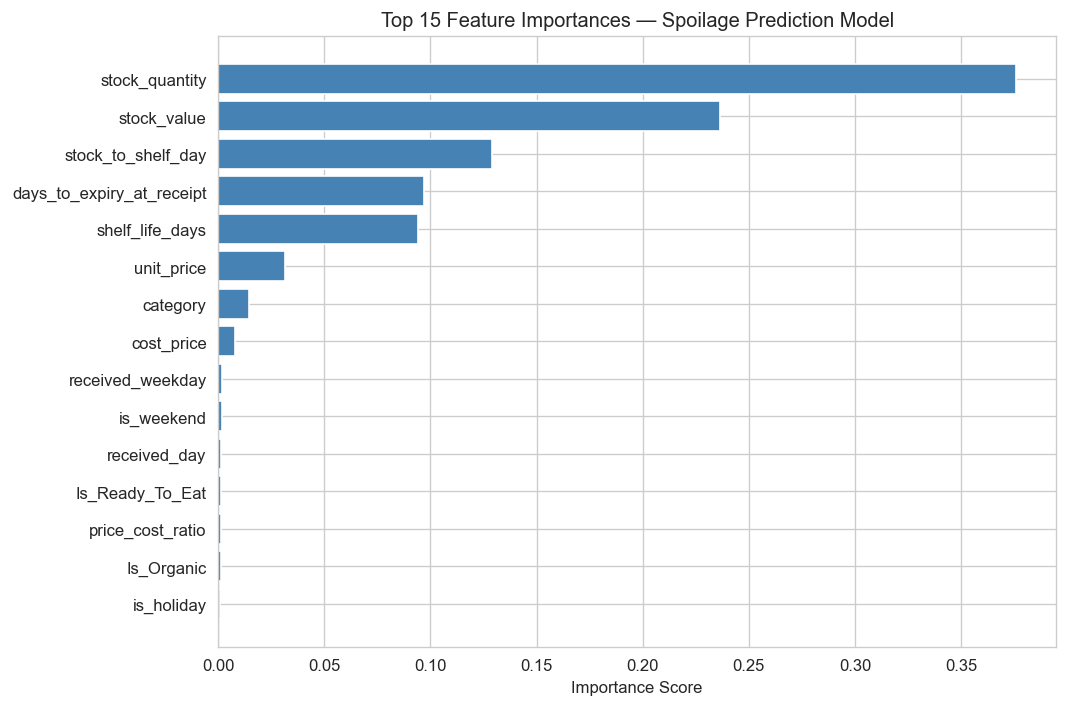

In [16]:
# Feature Importances — Spoilage Model
imp_s = pd.DataFrame({'Feature': X_train_s.columns,
                       'Importance': model_spoil.feature_importances_})
imp_s = imp_s.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(9, 6))
plt.barh(imp_s['Feature'][::-1], imp_s['Importance'][::-1], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importances — Spoilage Prediction Model')
plt.tight_layout(); plt.show()

## Phase 2 — Demand Forecasting

### Part 1 — Regression-Based Demand Forecasting

**Target:** `log1p(units_sold)` — log-transformed to fix right-skew (~4.3 raw)

**Leakage Fix:**
- `sales_demand_n` → **removed** (binned encoding of `units_sold` — direct target leak)
- `sales_date` → **removed** (not known before the sale)
- `discount_applied_percent`, `promotional_price` → **removed** (sale-time info)
- `final_profit` → **removed** (contains `units_sold`)
- All date features extracted from `received_date` only (pre-sale safe)

### Inference 17
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# ── Build target ──────────────────────────────────────────────────────────
# log1p transform: fixes heavy right-skew (raw skew ~4.3) for better regression
y_demand_raw   = df['units_sold']
df['log_demand'] = np.log1p(y_demand_raw)

print(f"units_sold  skewness (raw)         : {y_demand_raw.skew():.2f}")
print(f"log_demand  skewness (log-transformed): {df['log_demand'].skew():.2f}")

# ── Time-based split ──────────────────────────────────────────────────────
print("\nSplitting:")
train_d, test_d, _ = time_split(df, date_col='received_date', ratio=0.80)

X_train_d, enc_demand = prepare_X(train_d, PRE_SALE_FEATURES, CATEGORICAL_FEATURES, fit=True)
X_test_d,  _          = prepare_X(test_d,  PRE_SALE_FEATURES, CATEGORICAL_FEATURES,
                                   encoders=enc_demand, fit=False)
X_test_d = X_test_d.reindex(columns=X_train_d.columns, fill_value=0)

y_train_d = train_d['log_demand']
y_test_d  = test_d['log_demand']

print(f"\nFeature matrix: {X_train_d.shape[1]} features")
print("Leakage check:", "✅ CLEAN" if not (ALL_LEAKAGE & set(X_train_d.columns)) else "❌ LEAKAGE")

units_sold  skewness (raw)         : 2.06
log_demand  skewness (log-transformed): -0.07

Splitting:
  Split on 'received_date': Train=72,699 | Test=18,175 | Cutoff=2025-02-09

Feature matrix: 27 features
Leakage check: ✅ CLEAN


### Inference 18
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [18]:
# ── Train ─────────────────────────────────────────────────────────────────
model_demand = RandomForestRegressor(
    n_estimators     = 150,
    max_depth        = 8,
    min_samples_split= 20,
    min_samples_leaf = 10,
    random_state     = 42,
    n_jobs           = -1
)
model_demand.fit(X_train_d, y_train_d)

preds_log     = model_demand.predict(X_test_d)
preds_actual  = np.expm1(preds_log)
y_test_actual = np.expm1(y_test_d)

mae_d  = mean_absolute_error(y_test_actual, preds_actual)
rmse_d = np.sqrt(((y_test_actual - preds_actual) ** 2).mean())
r2_d   = r2_score(y_test_d, preds_log)

# FIX #3: Compute train R² for overfitting check
r2_d_train    = r2_score(y_train_d, model_demand.predict(X_train_d))
preds_train_actual = np.expm1(model_demand.predict(X_train_d))
y_train_actual     = np.expm1(y_train_d)
mae_d_train        = mean_absolute_error(y_train_actual, preds_train_actual)
gap_r2             = r2_d_train - r2_d

print("Demand Forecasting Regressor — Train vs Test (Fix #3):")
print(f"  Train R² (log space)   : {r2_d_train:.4f}")
print(f"  Test  R² (log space)   : {r2_d:.4f}")
print(f"  Overfitting gap        : {gap_r2:.4f}  {'⚠️  Overfitting' if gap_r2 > 0.03 else '✅ No overfitting'}")
print()
print("  Train MAE (original scale): {:.2f} units".format(mae_d_train))
print(f"  Test  MAE (original scale): {mae_d:.2f} units")
print(f"  Test  RMSE (original scale): {rmse_d:.2f} units")
print()
print("NOTE: R² is measured in log space. MAE/RMSE are in original units after expm1().")
print("      Do not compare this R² directly to a model trained on raw units_sold.")


### Inference 19
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


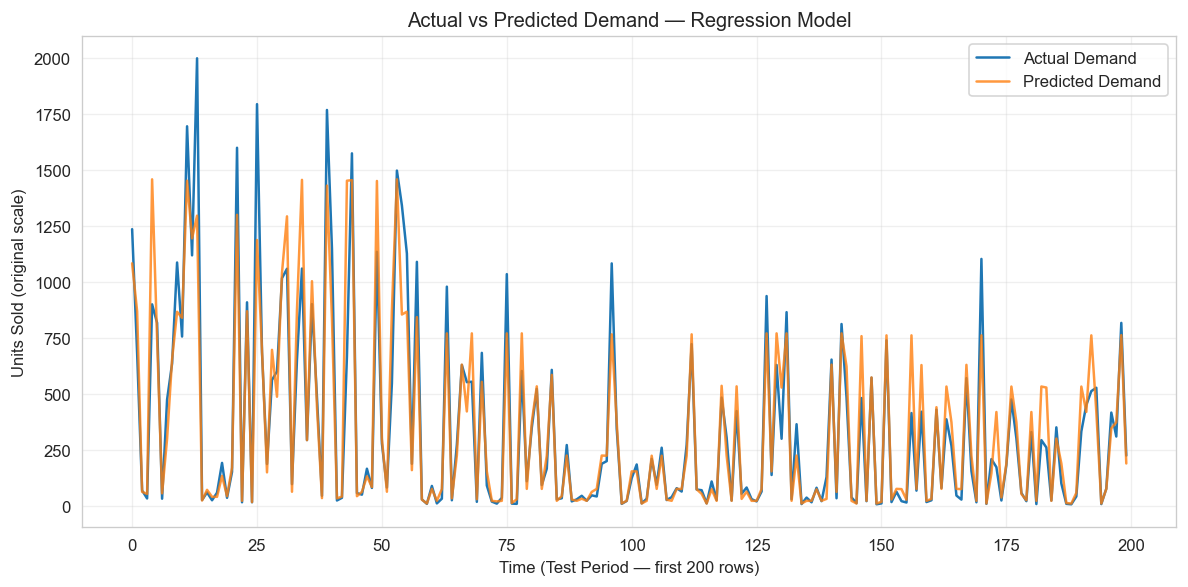

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(y_test_actual.values[:200], label='Actual Demand', linewidth=1.5)
plt.plot(preds_actual[:200],         label='Predicted Demand', linewidth=1.5, alpha=0.8)
plt.xlabel("Time (Test Period — first 200 rows)")
plt.ylabel("Units Sold (original scale)")
plt.title("Actual vs Predicted Demand — Regression Model")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Part 2 — Demand & Waste Models with LabelEncoder

**Leakage Fix:**
- All leakage columns removed from both models
- `encoders` dict created before training (was `NameError` crash in original notebook)
- Random split replaced with strict time-based split for both models

### Inference 20
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [20]:
import joblib

# ── FIX #2: Perform time-based split FIRST, then fit encoders on train only ─
# (Previously encoders were fitted on full df including test rows — now fixed)
categorical_cols = ['category', 'store_location']

df_sorted = df.copy().sort_values('received_date').reset_index(drop=True)
df_sorted['received_month']       = df_sorted['received_date'].dt.month
df_sorted['received_day_of_week'] = df_sorted['received_date'].dt.dayofweek

# Split FIRST
split_idx_enc  = int(len(df_sorted) * 0.80)
df_train_enc   = df_sorted.iloc[:split_idx_enc].copy()
df_test_enc    = df_sorted.iloc[split_idx_enc:].copy()

# Fit encoders on TRAIN only
encoders     = {}
df_encoded   = df_sorted.copy()
for col in categorical_cols:
    le = LabelEncoder()
    train_vals = df_train_enc[col].fillna('Unknown').astype(str)
    le.fit(train_vals)                                  # fit on train only
    known = set(le.classes_)
    # Map unseen test values to 'Unknown' before transforming
    df_encoded[col] = df_sorted[col].fillna('Unknown').astype(str).apply(
        lambda x: x if x in known else 'Unknown'
    )
    df_encoded[col] = le.transform(df_encoded[col])
    encoders[col]   = le

print("Label encoders fitted on TRAIN set only (Fix #2)")
print("Encoders created for:", list(encoders.keys()))
for col in categorical_cols:
    print(f"  {col}: {len(encoders[col].classes_)} known classes from train")


### Inference 21
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [21]:
# Model A — Demand Forecasting (uses Fix #2 encoders)
print("Training Demand Forecasting Model...")

demand_features = [
    'stock_quantity', 'shelf_life_days', 'unit_price', 'cost_price',
    'is_holiday', 'is_weekend', 'Is_Organic', 'Is_Ready_To_Eat',
    'received_month', 'received_day_of_week', 'category', 'store_location',
    'Temperature_C', 'Humidity_Percent', 'weather_severity_n',
    'lead_time_days', 'supply_delay_days', 'high_temp_flag',
    'days_to_expiry_at_receipt', 'stock_to_shelf_day', 'price_cost_ratio',
]

# Leakage check
assert not (ALL_LEAKAGE & set(demand_features)), "Leakage in demand features!"

# Time-based split on df_encoded (encoders fitted on train only — Fix #2)
df_dem_sorted = df_encoded.sort_values('received_date').reset_index(drop=True)
split_idx     = int(len(df_dem_sorted) * 0.80)

Xd_train = df_dem_sorted[demand_features].iloc[:split_idx]
Xd_test  = df_dem_sorted[demand_features].iloc[split_idx:]
yd_train = df_dem_sorted['units_sold'].iloc[:split_idx]
yd_test  = df_dem_sorted['units_sold'].iloc[split_idx:]

demand_model = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
demand_model.fit(Xd_train, yd_train)

# FIX #3: Train AND test R²
r2_dem_train = demand_model.score(Xd_train, yd_train)
r2_dem       = demand_model.score(Xd_test,  yd_test)
mae_dem      = mean_absolute_error(yd_test, demand_model.predict(Xd_test))
gap_dem      = r2_dem_train - r2_dem

print(f"Demand Model — Train R²: {r2_dem_train:.4f} | Test R²: {r2_dem:.4f} | Gap: {gap_dem:.4f}  "
      f"{'⚠️  Overfitting' if gap_dem > 0.05 else '✅ No overfitting'}")
print(f"Test MAE: {mae_dem:.2f} units")

joblib.dump(demand_model, 'demand_forecast_model.pkl')
joblib.dump(encoders,     'label_encoders.pkl')
print("Saved: demand_forecast_model.pkl, label_encoders.pkl")


### Inference 22
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [22]:
# Model B — Waste / Spoilage Risk (uses Fix #2 encoders)
print("Training Spoilage Risk Models...")

waste_features = [
    'stock_quantity', 'shelf_life_days', 'category', 'store_location',
    'Temperature_C', 'Humidity_Percent', 'weather_severity_n',
    'lead_time_days', 'supply_delay_days', 'Is_Organic', 'Is_Ready_To_Eat',
    'days_to_expiry_at_receipt', 'stock_to_shelf_day', 'high_temp_flag',
    'price_cost_ratio', 'received_month',
]

# Leakage check
assert not (ALL_LEAKAGE & set(waste_features)), "Leakage in waste features!"

df_waste_sorted = df_encoded.sort_values('received_date').reset_index(drop=True)
split_idx_w     = int(len(df_waste_sorted) * 0.80)

Xw_train = df_waste_sorted[waste_features].iloc[:split_idx_w]
Xw_test  = df_waste_sorted[waste_features].iloc[split_idx_w:]
yw_train = df_waste_sorted['waste_quantity'].iloc[:split_idx_w]
yw_test  = df_waste_sorted['waste_quantity'].iloc[split_idx_w:]

# ── Model B1: Raw waste volume (original) ─────────────────────────────────
waste_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
waste_model.fit(Xw_train, yw_train)

# FIX #3: Train AND test scores
r2_wst_train = waste_model.score(Xw_train, yw_train)
r2_wst       = waste_model.score(Xw_test,  yw_test)
mae_wst      = mean_absolute_error(yw_test, waste_model.predict(Xw_test))
gap_wst      = r2_wst_train - r2_wst

print(f"\nWaste Volume Model — Train R²: {r2_wst_train:.4f} | Test R²: {r2_wst:.4f} | Gap: {gap_wst:.4f}  "
      f"{'⚠️  Overfitting' if gap_wst > 0.05 else '✅ No overfitting'}")
print(f"Test MAE: {mae_wst:.2f} units")

# ── FIX #4: Model B2 — Waste RATE model (waste / stock) ───────────────────
# This removes the trivial stock_quantity→waste correlation and tests
# whether features predict HOW EFFICIENTLY stock is wasted, not just volume.
yw_rate_train = (df_waste_sorted['waste_quantity'] / (df_waste_sorted['stock_quantity'] + 1)).iloc[:split_idx_w]
yw_rate_test  = (df_waste_sorted['waste_quantity'] / (df_waste_sorted['stock_quantity'] + 1)).iloc[split_idx_w:]

waste_rate_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
waste_rate_model.fit(Xw_train, yw_rate_train)

r2_rate_train = waste_rate_model.score(Xw_train, yw_rate_train)
r2_rate_test  = waste_rate_model.score(Xw_test,  yw_rate_test)
mae_rate      = mean_absolute_error(yw_rate_test, waste_rate_model.predict(Xw_test))
gap_rate      = r2_rate_train - r2_rate_test

print(f"\nWaste RATE Model   — Train R²: {r2_rate_train:.4f} | Test R²: {r2_rate_test:.4f} | Gap: {gap_rate:.4f}  "
      f"{'⚠️  Overfitting' if gap_rate > 0.05 else '✅ No overfitting'}")
print(f"Test MAE (waste rate): {mae_rate:.4f}")
print()
print("INTERPRETATION: If waste-rate R² << waste-volume R², the volume model")
print("was mostly learning 'big order → big waste' (trivial). The rate model")
print("reveals whether features can genuinely predict spoilage efficiency.")

joblib.dump(waste_model,      'spoilage_risk_model.pkl')
joblib.dump(waste_rate_model, 'spoilage_rate_model.pkl')
print("\nSaved: spoilage_risk_model.pkl, spoilage_rate_model.pkl")


### Part 3 — Time Series Demand Forecasting

**Models:** Prophet (seasonal decomposition) + XGBoost with lag features

**Leakage Fixes for Time-Series:**
1. All lag features use `shift(lag)` — never `shift(0)` (which would include current-day sales)
2. Rolling features use `shift(1).rolling(n)` — prevents look-ahead bias where rolling mean at time t would include the value at t itself
3. Train/test cutoff is date-based, not `iloc` on unsorted data
4. Walk-forward forecast uses only accumulated history — no peeking at future test rows

### Inference 23
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [23]:
# !pip install prophet xgboost -q
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
print("Prophet and XGBoost ready.")

Prophet and XGBoost ready.


### Inference 24
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [24]:
# Aggregate to daily store level
# NOTE: sales_date is used ONLY for time-series aggregation (not as a feature)
df['sales_date'] = pd.to_datetime(df['sales_date'])

daily_store = (
    df
    .groupby(['sales_date', 'store_id'])
    .agg(
        sales_volume = ('units_sold',          'sum'),   # target (y) only
        avg_temp     = ('Temperature_C',       'mean'),  # pre-sale observable
        weather_sev  = ('weather_severity_n',  'max'),   # pre-sale observable
        is_holiday   = ('is_holiday',          'max'),   # calendar feature
        is_weekend   = ('is_weekend',          'max'),   # calendar feature
    )
    .reset_index()
    .sort_values(['store_id', 'sales_date'])
)

def fill_missing_dates(df_store, date_col='sales_date'):
    full_range = pd.date_range(df_store[date_col].min(), df_store[date_col].max(), freq='D')
    df_store   = (df_store.set_index(date_col)
                           .reindex(full_range).fillna(0)
                           .reset_index()
                           .rename(columns={'index': date_col}))
    return df_store

stores    = sorted(daily_store['store_id'].unique())
store_dfs = {}
for store in stores:
    s = daily_store[daily_store['store_id'] == store].copy()
    s = fill_missing_dates(s)
    store_dfs[store] = s

print(f"Stores processed: {len(stores)}")
print(f"Store_1 date range: {store_dfs['Store_1']['sales_date'].min().date()} → {store_dfs['Store_1']['sales_date'].max().date()}")

Stores processed: 10
Store_1 date range: 2022-12-09 → 2029-09-19


### Inference 25
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


Train: 2022-12-09 → 2028-05-11 (1981 days)
Test : 2028-05-12 → 2029-09-19 (496 days)


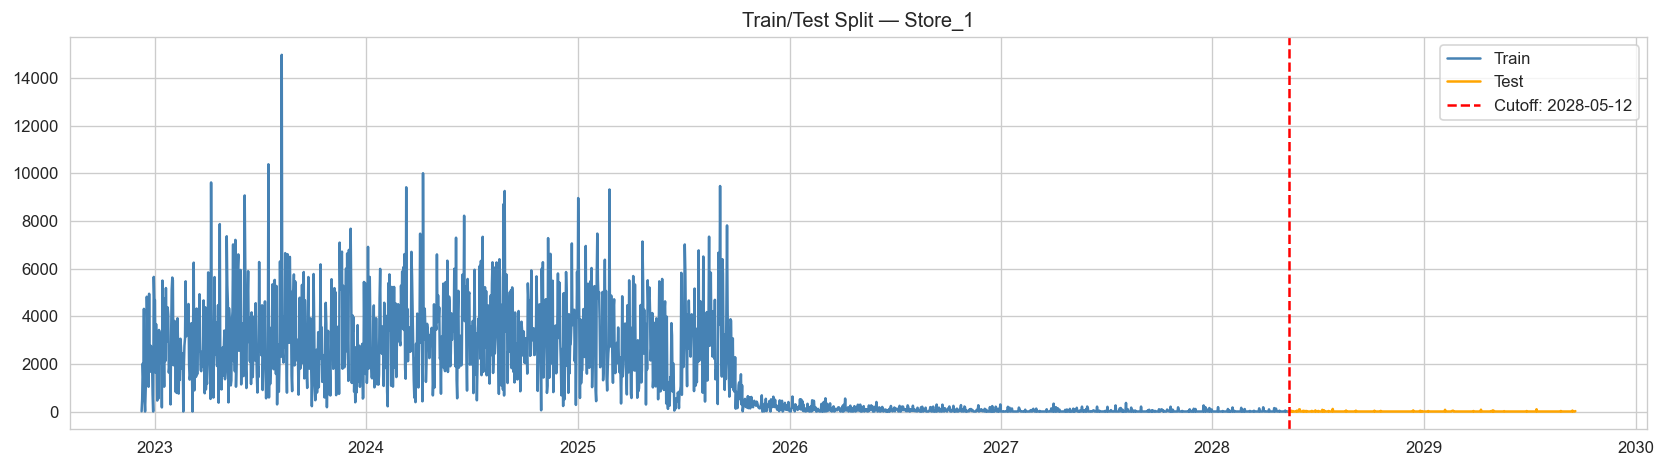

In [25]:
# Time-based split for demo store (date-based, not iloc-based)
DEMO_STORE  = 'Store_1'
df_ts       = store_dfs[DEMO_STORE].copy()
cutoff_date = df_ts['sales_date'].quantile(0.80, interpolation='nearest')
train_df    = df_ts[df_ts['sales_date'] <  cutoff_date].copy()
test_df     = df_ts[df_ts['sales_date'] >= cutoff_date].copy()

print(f"Train: {train_df['sales_date'].min().date()} → {train_df['sales_date'].max().date()} ({len(train_df)} days)")
print(f"Test : {test_df['sales_date'].min().date()} → {test_df['sales_date'].max().date()} ({len(test_df)} days)")

plt.figure(figsize=(14, 4))
plt.plot(train_df['sales_date'], train_df['sales_volume'], label='Train', color='steelblue')
plt.plot(test_df['sales_date'],  test_df['sales_volume'],  label='Test',  color='orange')
plt.axvline(cutoff_date, color='red', linestyle='--', label=f'Cutoff: {cutoff_date.date()}')
plt.title(f"Train/Test Split — {DEMO_STORE}")
plt.legend(); plt.tight_layout(); plt.show()

#### Model 1 — Prophet (Interpretable Seasonality)

### Inference 26
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [26]:
train_prophet = train_df.rename(columns={'sales_date': 'ds', 'sales_volume': 'y'})
test_prophet  = test_df.rename(columns={'sales_date': 'ds', 'sales_volume': 'y'})

prophet_model = Prophet(
    yearly_seasonality      = True,
    weekly_seasonality      = True,
    daily_seasonality       = False,
    seasonality_mode        = 'multiplicative',
    changepoint_prior_scale = 0.05,
    interval_width          = 0.95
)
# Only pre-sale observables added as regressors (NOT units_sold, waste_quantity, discount)
prophet_model.add_regressor('is_holiday')   # ✅ calendar — pre-sale safe
prophet_model.add_regressor('weather_sev')  # ✅ observable — pre-sale safe
prophet_model.fit(train_prophet[['ds', 'y', 'is_holiday', 'weather_sev']])

future_df  = test_df.rename(columns={'sales_date': 'ds'})[['ds', 'is_holiday', 'weather_sev']]
forecast_p = prophet_model.predict(future_df)

mae_p  = mean_absolute_error(test_df['sales_volume'], forecast_p['yhat'])
rmse_p = np.sqrt(mean_squared_error(test_df['sales_volume'], forecast_p['yhat']))
print(f"Prophet — MAE: {mae_p:,.1f} | RMSE: {rmse_p:,.1f}")

00:29:23 - cmdstanpy - INFO - Chain [1] start processing
00:29:27 - cmdstanpy - INFO - Chain [1] done processing


Prophet — MAE: 48.3 | RMSE: 53.7


### Inference 27
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


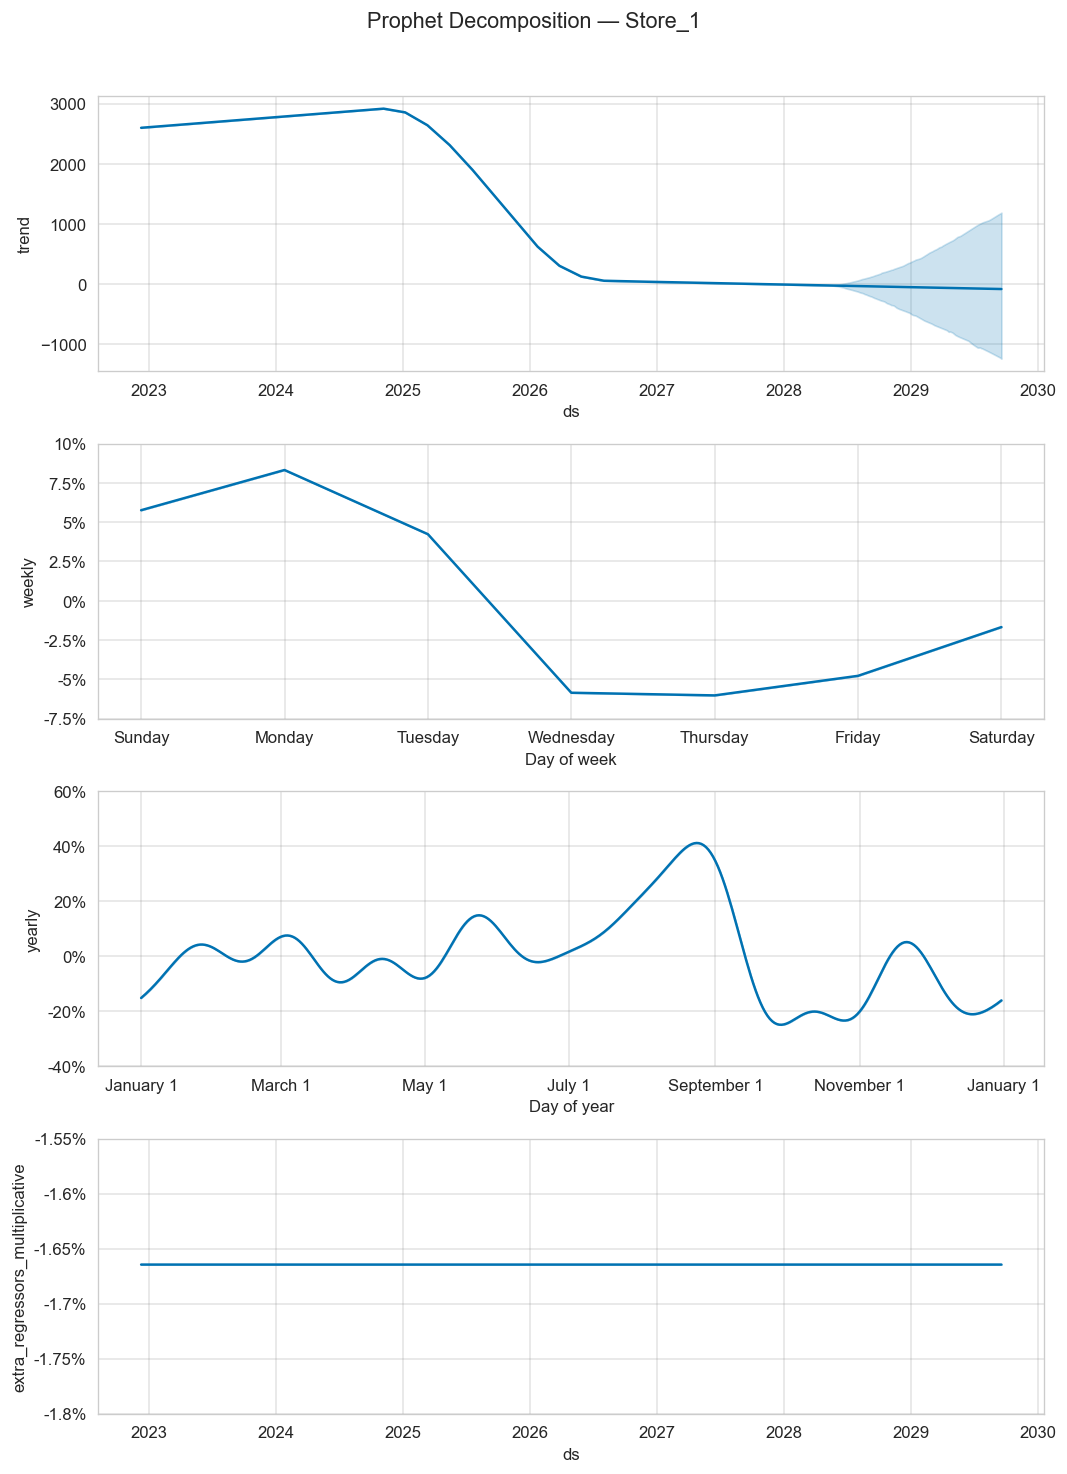

In [27]:
# Prophet Decomposition
future_full = prophet_model.make_future_dataframe(periods=len(test_df), freq='D')
future_full['is_holiday']  = 0
future_full['weather_sev'] = 1
forecast_full = prophet_model.predict(future_full)

fig = prophet_model.plot_components(forecast_full)
fig.suptitle(f'Prophet Decomposition — {DEMO_STORE}', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

#### Model 2 — XGBoost with Lag Features (High Accuracy)

**Leakage Fix for Lags:**
- `lag_Nd = series.shift(N)` — value N days ago (never current day)
- Rolling windows: `series.shift(1).rolling(N).mean()` — shift(1) ensures the window never includes the current observation (look-ahead bias prevention)

### Inference 28
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [28]:
def create_lag_features(df, target_col='sales_volume', lags=[1, 3, 7, 14, 30]):
    """
    Build lag and rolling features with strict look-ahead prevention.
    shift(1) before rolling ensures window at time t does NOT include value at t.
    """
    df = df.copy().sort_values('sales_date').reset_index(drop=True)

    # Lag features: shift(N) gives value from N days ago — safe
    for lag in lags:
        df[f'lag_{lag}d'] = df[target_col].shift(lag)

    # Rolling features: shift(1) FIRST prevents look-ahead at current observation
    shifted = df[target_col].shift(1)
    df['rolling_7d_mean']  = shifted.rolling(7,  min_periods=1).mean()
    df['rolling_14d_mean'] = shifted.rolling(14, min_periods=1).mean()
    df['rolling_30d_mean'] = shifted.rolling(30, min_periods=1).mean()
    df['rolling_7d_std']   = shifted.rolling(7,  min_periods=1).std().fillna(0)

    # Calendar features from sales_date (known at prediction time — these are date stamps)
    df['day_of_week']    = df['sales_date'].dt.dayofweek
    df['day_of_month']   = df['sales_date'].dt.day
    df['month']          = df['sales_date'].dt.month
    df['week_of_year']   = df['sales_date'].dt.isocalendar().week.astype(int)
    df['quarter']        = df['sales_date'].dt.quarter
    df['is_month_end']   = df['sales_date'].dt.is_month_end.astype(int)
    df['is_month_start'] = df['sales_date'].dt.is_month_start.astype(int)
    return df

feature_cols = [
    'lag_1d', 'lag_3d', 'lag_7d', 'lag_14d', 'lag_30d',
    'rolling_7d_mean', 'rolling_14d_mean', 'rolling_30d_mean', 'rolling_7d_std',
    'day_of_week', 'day_of_month', 'month', 'week_of_year', 'quarter',
    'is_month_end', 'is_month_start',
    'avg_temp', 'weather_sev', 'is_holiday', 'is_weekend',
]
print("Lag feature builder defined — all features use shift() for look-ahead safety.")

Lag feature builder defined — all features use shift() for look-ahead safety.


### Inference 29
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [29]:
print("Training per-store XGBoost models...")
store_models  = {}
store_metrics = {}

for store in stores:
    df_s   = create_lag_features(store_dfs[store].copy()).dropna()
    X      = df_s[feature_cols]
    y      = df_s['sales_volume']

    # Strict date-based split
    split_date = df_s['sales_date'].quantile(0.80, interpolation='nearest')
    X_tr = X[df_s['sales_date'] <  split_date]
    X_te = X[df_s['sales_date'] >= split_date]
    y_tr = y[df_s['sales_date'] <  split_date]
    y_te = y[df_s['sales_date'] >= split_date]

    model_xgb = XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, n_jobs=-1
    )
    model_xgb.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)

    preds_xgb = np.maximum(model_xgb.predict(X_te), 0)
    mae_xgb   = mean_absolute_error(y_te, preds_xgb)
    rmse_xgb  = np.sqrt(mean_squared_error(y_te, preds_xgb))
    mask      = y_te > 10
    mape_xgb  = (np.abs((y_te[mask] - preds_xgb[mask]) / (y_te[mask] + 1))).mean() * 100 if mask.sum() > 0 else 0

    store_models[store]  = model_xgb
    store_metrics[store] = {'MAE': mae_xgb, 'RMSE': rmse_xgb, 'MAPE': mape_xgb}
    print(f"  {store}: MAE={mae_xgb:,.1f}  RMSE={rmse_xgb:,.1f}  MAPE={mape_xgb:.1f}%")

xgb_model = store_models['Store_1']
joblib.dump(store_models, 'timeseries_xgb_model.pkl')
print(f"\nAvg MAE : {np.mean([v['MAE']  for v in store_metrics.values()]):,.1f}")
print(f"Avg RMSE: {np.mean([v['RMSE'] for v in store_metrics.values()]):,.1f}")
print("Saved: timeseries_xgb_model.pkl")

Training per-store XGBoost models...
  Store_1: MAE=5.7  RMSE=24.9  MAPE=180.7%
  Store_10: MAE=3.7  RMSE=9.4  MAPE=134.7%
  Store_2: MAE=4.7  RMSE=15.5  MAPE=199.6%
  Store_3: MAE=7.8  RMSE=14.9  MAPE=165.6%
  Store_4: MAE=3.7  RMSE=11.8  MAPE=192.2%
  Store_5: MAE=2.9  RMSE=11.8  MAPE=200.1%
  Store_6: MAE=10.8  RMSE=14.9  MAPE=112.2%
  Store_7: MAE=9.1  RMSE=13.9  MAPE=151.5%
  Store_8: MAE=7.1  RMSE=18.6  MAPE=187.5%
  Store_9: MAE=6.3  RMSE=12.8  MAPE=131.2%

Avg MAE : 6.2
Avg RMSE: 14.9
Saved: timeseries_xgb_model.pkl


### Inference 30
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


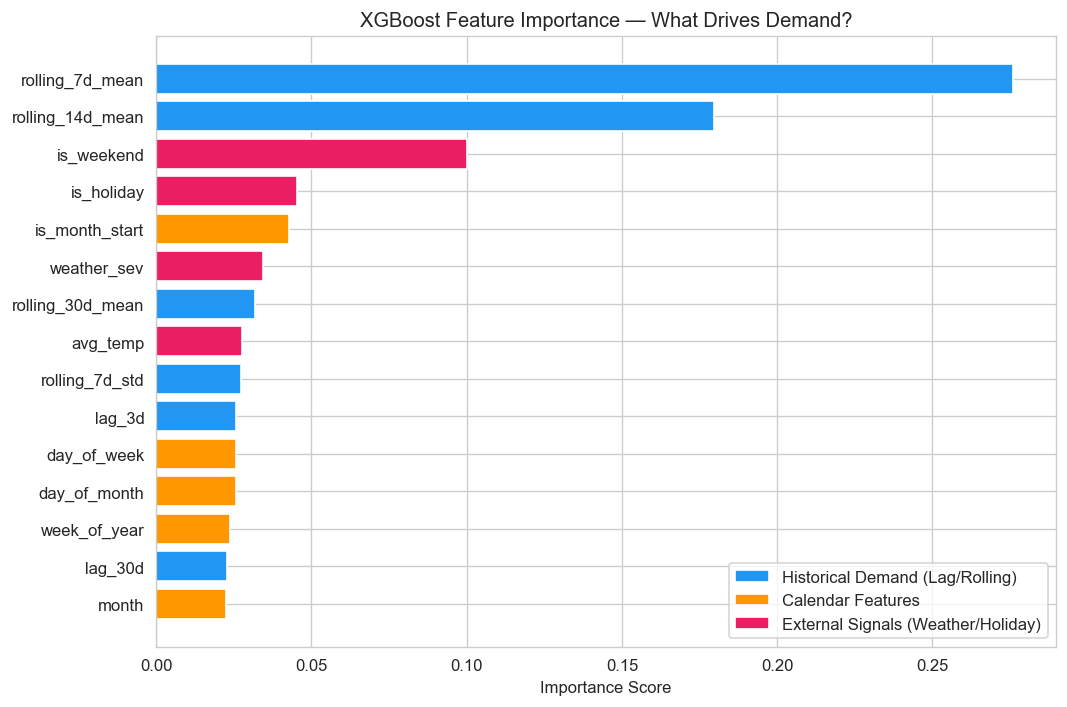

In [30]:
from matplotlib.patches import Patch

feat_imp_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

colors = ['#2196F3' if ('lag' in f or 'rolling' in f) else
          '#FF9800' if f in ['day_of_week','month','week_of_year','quarter',
                             'day_of_month','is_month_end','is_month_start'] else
          '#E91E63'
          for f in feat_imp_df['Feature']]

plt.figure(figsize=(9, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color=colors)
plt.xlabel('Importance Score')
plt.title('XGBoost Feature Importance — What Drives Demand?')
legend_elements = [
    Patch(facecolor='#2196F3', label='Historical Demand (Lag/Rolling)'),
    Patch(facecolor='#FF9800', label='Calendar Features'),
    Patch(facecolor='#E91E63', label='External Signals (Weather/Holiday)'),
]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout(); plt.show()

### Inference 31
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [31]:
# 30-Day Walk-Forward Forecast
FORECAST_HORIZON = 30

def forecast_next_n_days(store_df, model, feature_cols, n_days=30):
    """
    True walk-forward forecast.
    At each step, only accumulated past history (including previous predictions)
    is used. No future rows are ever read.
    """
    df_pred   = create_lag_features(store_df.copy()).dropna()
    last_date = df_pred['sales_date'].max()
    history   = df_pred['sales_volume'].tolist()
    future_preds, future_dates = [], []

    for i in range(1, n_days + 1):
        next_date = last_date + pd.Timedelta(days=i)
        row = {
            'lag_1d'         : history[-1],
            'lag_3d'         : history[-3]  if len(history) >= 3  else history[0],
            'lag_7d'         : history[-7]  if len(history) >= 7  else history[0],
            'lag_14d'        : history[-14] if len(history) >= 14 else history[0],
            'lag_30d'        : history[-30] if len(history) >= 30 else history[0],
            'rolling_7d_mean' : np.mean(history[-7:]),
            'rolling_14d_mean': np.mean(history[-14:]),
            'rolling_30d_mean': np.mean(history[-30:]),
            'rolling_7d_std'  : np.std(history[-7:]),
            'day_of_week'    : next_date.dayofweek,
            'day_of_month'   : next_date.day,
            'month'          : next_date.month,
            'week_of_year'   : next_date.isocalendar()[1],
            'quarter'        : (next_date.month - 1) // 3 + 1,
            'is_month_end'   : int(next_date == next_date + pd.offsets.MonthEnd(0)),
            'is_month_start' : int(next_date.day == 1),
            'avg_temp'       : store_df['avg_temp'].median(),
            'weather_sev'    : 1,
            'is_holiday'     : 0,
            'is_weekend'     : int(next_date.dayofweek >= 5),
        }
        pred = max(0, float(model.predict(pd.DataFrame([row])[feature_cols])[0]))
        future_preds.append(pred); future_dates.append(next_date)
        history.append(pred)  # use prediction as input for next step

    return pd.DataFrame({'date': future_dates, 'forecasted_demand': future_preds})

print("Generating 30-day walk-forward forecasts for all stores...")
all_store_forecasts = {}
for store in stores:
    fc           = forecast_next_n_days(store_dfs[store], store_models[store], feature_cols, FORECAST_HORIZON)
    fc['store_id'] = store
    all_store_forecasts[store] = fc
    print(f"  {store}: avg {fc['forecasted_demand'].mean():,.0f} units/day")

forecast_master = pd.concat(all_store_forecasts.values(), ignore_index=True)
forecast_master = forecast_master[['store_id', 'date', 'forecasted_demand']]
forecast_master['date']              = pd.to_datetime(forecast_master['date'])
forecast_master['forecasted_demand'] = forecast_master['forecasted_demand'].round(0).astype(int)
forecast_master.to_csv('demand_forecast_30days.csv', index=False)
print("Saved: demand_forecast_30days.csv")

Generating 30-day walk-forward forecasts for all stores...
  Store_1: avg 72 units/day
  Store_10: avg 62 units/day
  Store_2: avg 73 units/day
  Store_3: avg 57 units/day
  Store_4: avg 75 units/day
  Store_5: avg 57 units/day
  Store_6: avg 59 units/day
  Store_7: avg 75 units/day
  Store_8: avg 80 units/day
  Store_9: avg 83 units/day
Saved: demand_forecast_30days.csv


### Inference 32
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


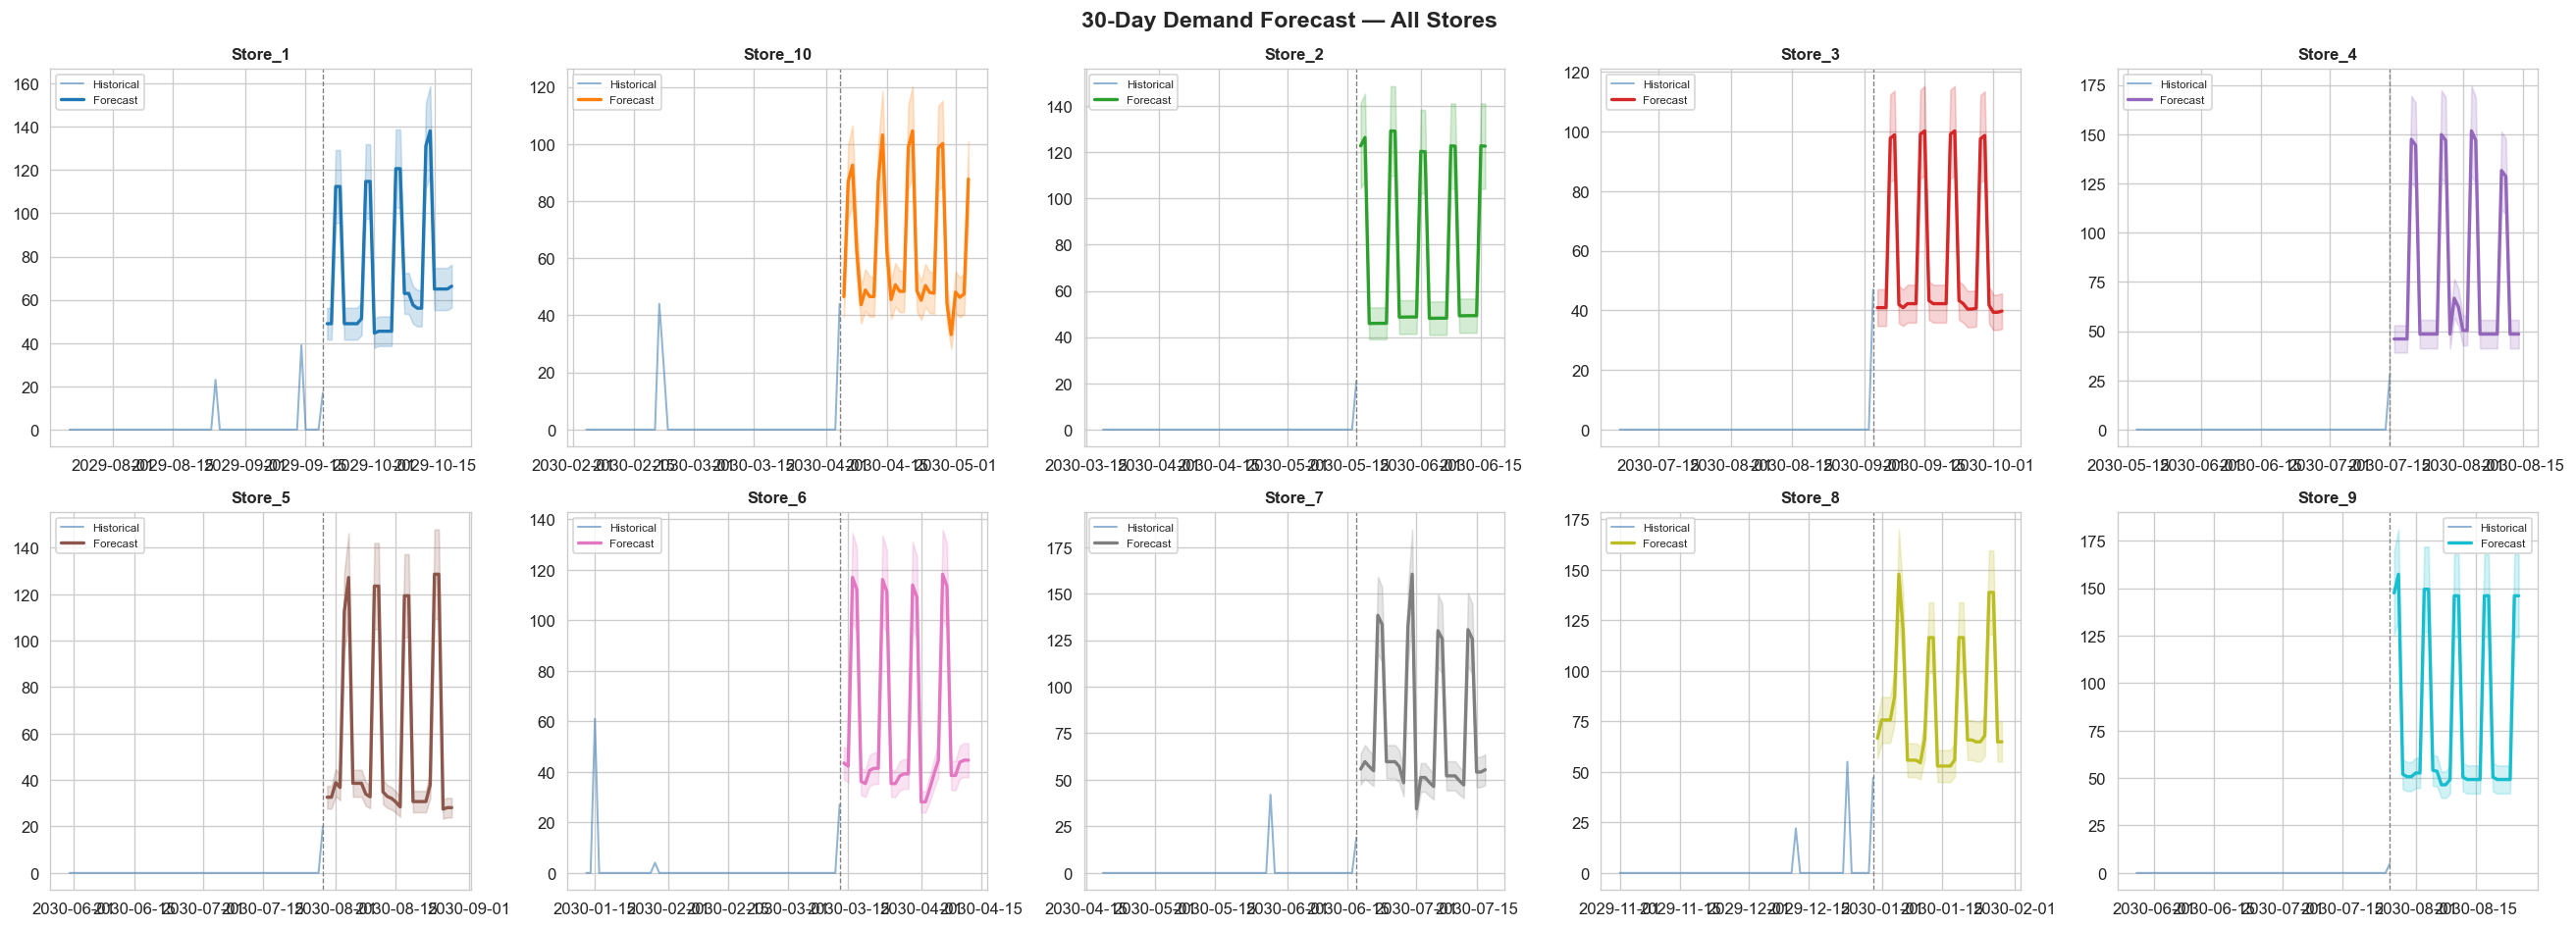

In [32]:
# All-Store Forecast Dashboard
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes      = axes.flatten()
palette   = plt.cm.tab10.colors

for idx, store in enumerate(sorted(stores)):
    ax   = axes[idx]
    fc   = all_store_forecasts[store]
    hist = store_dfs[store].tail(60)
    ax.plot(hist['sales_date'],  hist['sales_volume'],    color='steelblue', alpha=0.6, linewidth=1.2, label='Historical')
    ax.plot(fc['date'],          fc['forecasted_demand'], color=palette[idx], linewidth=2, label='Forecast')
    ax.axvline(hist['sales_date'].max(), color='gray', linestyle='--', linewidth=0.8)
    ax.fill_between(fc['date'],
                    fc['forecasted_demand'] * 0.85,
                    fc['forecasted_demand'] * 1.15,
                    alpha=0.2, color=palette[idx])
    ax.set_title(store, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)

plt.suptitle('30-Day Demand Forecast — All Stores', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### Inference 33
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [33]:
def generate_demand_insights(forecast_df):
    insights     = []
    store_total  = forecast_df.groupby('store_id')['forecasted_demand'].sum().sort_values(ascending=False)
    store_daily  = forecast_df.groupby('store_id')['forecasted_demand'].mean()
    insights.append("30-DAY DEMAND FORECAST (Total Units per Store):")
    for store, total in store_total.items():
        insights.append(f"  {store}: {total:,} units total  |  {store_daily[store]:,.0f} units/day avg")
    top_store = store_total.idxmax(); low_store = store_total.idxmin()
    insights.append(f"\nHIGH DEMAND ALERT: {top_store} → {store_total.max():,} units. Prioritize replenishment.")
    insights.append(f"LOW DEMAND ALERT:  {low_store} → {store_total.min():,} units. Consider redistribution.")
    forecast_df2 = forecast_df.copy()
    forecast_df2['is_weekend_fc'] = pd.to_datetime(forecast_df2['date']).dt.dayofweek >= 5
    weekend_avg = forecast_df2[forecast_df2['is_weekend_fc']]['forecasted_demand'].mean()
    weekday_avg = forecast_df2[~forecast_df2['is_weekend_fc']]['forecasted_demand'].mean()
    if weekend_avg > weekday_avg * 1.05:
        pct = ((weekend_avg / weekday_avg) - 1) * 100
        insights.append(f"\nWEEKEND SURGE: Weekend demand is {pct:.0f}% higher. Increase stock before weekends.")
    insights.append(f"\nTOP 3 REPLENISHMENT PRIORITY: {', '.join(store_total.head(3).index.tolist())}")
    return "\n".join(insights)

insight_text = generate_demand_insights(forecast_master)
print(insight_text)
with open('demand_agent_context.txt', 'w', encoding='utf-8') as f:
    f.write(insight_text)
print("\nSaved: demand_agent_context.txt")

30-DAY DEMAND FORECAST (Total Units per Store):
  Store_9: 2,480 units total  |  83 units/day avg
  Store_8: 2,407 units total  |  80 units/day avg
  Store_7: 2,236 units total  |  75 units/day avg
  Store_4: 2,233 units total  |  74 units/day avg
  Store_2: 2,199 units total  |  73 units/day avg
  Store_1: 2,157 units total  |  72 units/day avg
  Store_10: 1,871 units total  |  62 units/day avg
  Store_6: 1,761 units total  |  59 units/day avg
  Store_5: 1,711 units total  |  57 units/day avg
  Store_3: 1,701 units total  |  57 units/day avg

HIGH DEMAND ALERT: Store_9 → 2,480 units. Prioritize replenishment.
LOW DEMAND ALERT:  Store_3 → 1,701 units. Consider redistribution.

WEEKEND SURGE: Weekend demand is 157% higher. Increase stock before weekends.

TOP 3 REPLENISHMENT PRIORITY: Store_9, Store_8, Store_7

Saved: demand_agent_context.txt


## Phase 3 — LangChain Multi-Agent System

4 agents run in sequence:
1. **Inventory Agent** — stock levels, expiry, waste
2. **Demand Agent** — 30-day forecast, replenishment
3. **Weather Impact Agent** — temperature/humidity effects
4. **Decision Agent** — synthesizes all 3 reports → action plan

> **Prerequisite:** Run `ollama serve` in a terminal and pull `llama3` with `ollama pull llama3`

### Inference 34
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [34]:
!pip install -q langchain langchain-ollama langchain-core

### Inference 35
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [35]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from langchain_ollama import OllamaLLM
from langchain_core.prompts import PromptTemplate

llm  = OllamaLLM(model='llama3', temperature=0.3)
test = llm.invoke('Reply with only: Ollama is ready')
print(test)

Ollama is ready


### Inference 36
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [36]:
# Load fresh data for agents (all columns available for reporting purposes)
df_agents = pd.read_csv('LangChain_Perfected_Freshness_Dataset.csv')
for col in ['sales_date', 'expiry_date', 'received_date']:
    df_agents[col] = pd.to_datetime(df_agents[col])

forecast_df = pd.read_csv('demand_forecast_30days.csv')
forecast_df['date'] = pd.to_datetime(forecast_df['date'])

with open('demand_agent_context.txt', 'r', encoding='utf-8') as f:
    demand_context = f.read()

print('Dataset shape  :', df_agents.shape)
print('Forecast shape :', forecast_df.shape)
print('Stores         :', df_agents['store_id'].nunique())

Dataset shape  : (100192, 36)
Forecast shape : (300, 3)
Stores         : 10


### Inference 37
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [37]:
def run_inventory_agent(store_id, df, llm):
    store_df      = df[df['store_id'] == store_id].copy()
    total_stock   = store_df['stock_quantity'].sum()
    total_waste   = store_df['waste_quantity'].sum()
    waste_rate    = (total_waste / (total_stock + 1)) * 100
    danger_zone   = store_df[store_df['Days_to_Expiry_at_Sale'] <= 3]
    expiring_soon = danger_zone.groupby('product')['stock_quantity'].sum().sort_values(ascending=False).head(5)
    top_waste     = store_df.groupby('product')['waste_quantity'].sum().sort_values(ascending=False).head(5)
    low_stock     = store_df[store_df['stock_quantity'] < 50].groupby('product')['stock_quantity'].mean().sort_values().head(5)

    context = (
        f'Store ID: {store_id}\n'
        f'Total Stock: {total_stock:,} units\n'
        f'Total Waste: {total_waste:,} units\n'
        f'Waste Rate: {waste_rate:.1f}%\n\n'
        f'Products expiring within 3 days:\n{expiring_soon.to_string()}\n\n'
        f'Top 5 most wasted products:\n{top_waste.to_string()}\n\n'
        f'Low stock products (under 50 units):\n{low_stock.to_string() if len(low_stock) > 0 else "None"}\n'
    )
    prompt = PromptTemplate(
        input_variables=['context'],
        template=(
            'You are an Inventory Agent for a grocery retail chain.\n'
            'Based on the inventory data below, give clear recommendations.\n'
            'Be concise. Use bullet points. Focus on actions for TODAY.\n\n'
            'Inventory Data:\n{context}\n\n'
            'Provide:\n'
            '1. Spoilage Risk Summary (1-2 sentences)\n'
            '2. Urgent Actions (bullet points)\n'
            '3. Replenishment Needs (bullet points)\n'
        )
    )
    response = (prompt | llm).invoke({'context': context})
    return response, context

print('='*60); print('INVENTORY AGENT - Store_1'); print('='*60)
inv_response, inv_context = run_inventory_agent('Store_1', df_agents, llm)
print(inv_response)

INVENTORY AGENT - Store_1
**Spoilage Risk Summary:**
The store is at high risk of spoilage, with a waste rate of 78.7% and over 12 million units of stock expiring within the next few days. The products expiring soon are mostly perishable items like strawberries, ground beef, roast beef, peach, and pork chops.

**Urgent Actions:**

* Immediately review inventory levels for the top 5 most wasted products (strawberries, avocado, mango, peach, and lettuce) to identify root causes of waste.
* Conduct a thorough stock check to ensure all products expiring within 3 days are properly stored and rotated to minimize further spoilage.
* Alert store staff to prioritize sales of these perishable items to reduce waste.

**Replenishment Needs:**

* Reorder cashews, tofu, sugar, ice cream, and canned tuna as they are running low (under 50 units).
* Consider reordering strawberries, ground beef, roast beef, peach, and pork chops in bulk to replenish stock levels and minimize future spoilage.


### Inference 38
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [38]:
def run_demand_agent(store_id, forecast_df, demand_context, llm):
    store_fc    = forecast_df[forecast_df['store_id'] == store_id].copy()
    total_30d   = store_fc['forecasted_demand'].sum()
    avg_daily   = store_fc['forecasted_demand'].mean()
    peak_day    = store_fc.loc[store_fc['forecasted_demand'].idxmax()]
    low_day     = store_fc.loc[store_fc['forecasted_demand'].idxmin()]
    store_fc['is_weekend'] = pd.to_datetime(store_fc['date']).dt.dayofweek >= 5
    weekend_avg = store_fc[store_fc['is_weekend']]['forecasted_demand'].mean()
    weekday_avg = store_fc[~store_fc['is_weekend']]['forecasted_demand'].mean()
    next_7      = store_fc.head(7)

    context = (
        f'Store ID: {store_id}\n'
        f'30-Day Total Forecasted Demand: {total_30d:,} units\n'
        f'Average Daily Demand: {avg_daily:.0f} units/day\n'
        f'Peak Day: {peak_day["date"].strftime("%Y-%m-%d")} ({peak_day["forecasted_demand"]:,} units)\n'
        f'Lowest Day: {low_day["date"].strftime("%Y-%m-%d")} ({low_day["forecasted_demand"]:,} units)\n'
        f'Weekend Average: {weekend_avg:.0f} units/day\n'
        f'Weekday Average: {weekday_avg:.0f} units/day\n\n'
        f'Next 7 Days:\n{next_7[["date","forecasted_demand"]].to_string(index=False)}\n\n'
        f'Market Context:\n{demand_context}\n'
    )
    prompt = PromptTemplate(
        input_variables=['context'],
        template=(
            'You are a Demand Forecasting Agent for a grocery retail chain.\n'
            'Analyze the demand forecast and give replenishment recommendations.\n'
            'Be specific with quantities and dates. Use bullet points.\n\n'
            'Demand Forecast Data:\n{context}\n\n'
            'Provide:\n'
            '1. Demand Trend Summary (1-2 sentences)\n'
            '2. Replenishment Schedule (when and how much to order)\n'
            '3. Weekend Preparation Actions\n'
            '4. Risk Alerts (demand spikes or drops to watch)\n'
        )
    )
    response = (prompt | llm).invoke({'context': context})
    return response, context

print('='*60); print('DEMAND AGENT - Store_1'); print('='*60)
dem_response, dem_context = run_demand_agent('Store_1', forecast_df, demand_context, llm)
print(dem_response)

DEMAND AGENT - Store_1
**Demand Trend Summary:**
The demand forecast for Store_1 shows a consistent average daily demand of 72 units, with a peak day on October 14th and a lowest day on October 1st. The weekend surge is significant, with an increase of 157% in demand.

**Replenishment Schedule:**

* For the next 7 days:
	+ Order 49 units for September 20-24
	+ Order 112 units for September 22-23 (peak days)
	+ No order needed for September 25-26 (low demand)

Total replenishment quantity for the next 7 days: 313 units

**Weekend Preparation Actions:**
To prepare for the weekend surge, I recommend increasing stock by 30% (21.6 units) on Friday, September 22nd, to ensure adequate inventory levels.

**Risk Alerts:**

* **High Demand Alert:** Store_9's demand forecast is significantly higher than average at 2,480 units total. Prioritize replenishment for this store.
* **Low Demand Alert:** Store_3's demand forecast is lower than average at 1,701 units total. Consider redistributing excess 

### Inference 39
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [39]:
def run_weather_agent(store_id, df, llm):
    store_df      = df[df['store_id'] == store_id].copy()
    avg_temp      = store_df['Temperature_C'].mean()
    max_temp      = store_df['Temperature_C'].max()
    avg_humidity  = store_df['Humidity_Percent'].mean()
    high_temp_days= (store_df['Temperature_C'] > 30).sum()
    weather_waste = store_df.groupby('weather_severity_n')['waste_quantity'].mean().round(1)
    cat_impact    = store_df.groupby('category').agg(
        avg_waste      = ('waste_quantity','mean'),
        avg_temp       = ('Temperature_C','mean'),
        avg_shelf_life = ('shelf_life_days','mean')
    ).round(1).sort_values('avg_waste', ascending=False)
    heatwave_risk = 'HIGH' if avg_temp > 28 else 'MEDIUM' if avg_temp > 24 else 'LOW'

    context = (
        f'Store ID: {store_id}\n'
        f'Avg Temp: {avg_temp:.1f}C | Max Temp: {max_temp:.1f}C\n'
        f'Avg Humidity: {avg_humidity:.1f}%\n'
        f'High Temp Days (>30C): {high_temp_days}\n'
        f'Heatwave Risk: {heatwave_risk}\n\n'
        f'Waste by weather severity (0=mild,1=moderate,2=severe):\n{weather_waste.to_string()}\n\n'
        f'Category temp & waste impact:\n{cat_impact.to_string()}\n'
    )
    prompt = PromptTemplate(
        input_variables=['context'],
        template=(
            'You are a Weather Impact Agent for a grocery retail chain.\n'
            'Analyze weather data and estimate its impact on shelf life and spoilage.\n'
            'Give specific actionable advice. Use bullet points.\n\n'
            'Weather and Spoilage Data:\n{context}\n\n'
            'Provide:\n'
            '1. Weather Risk Summary (1-2 sentences)\n'
            '2. High Risk Product Categories\n'
            '3. Shelf Life Reduction Estimates\n'
            '4. Recommended Storage and Discount Actions\n'
        )
    )
    response = (prompt | llm).invoke({'context': context})
    return response, context

print('='*60); print('WEATHER IMPACT AGENT - Store_1'); print('='*60)
weather_response, weather_context = run_weather_agent('Store_1', df_agents, llm)
print(weather_response)

WEATHER IMPACT AGENT - Store_1
**Weather Risk Summary:**
Store_1 is at medium risk of heatwave, with an average temperature of 24.4C and a maximum temperature of 35.0C. This weather pattern may lead to increased spoilage and waste, particularly in categories that are sensitive to high temperatures.

**High Risk Product Categories:**

* Fresh Foods (avg_waste: 2586.5)
* Bakery (avg_waste: 1655.9)

These categories are most vulnerable to temperature fluctuations and humidity changes, which can accelerate spoilage and reduce shelf life.

**Shelf Life Reduction Estimates:**
Based on the provided data, we estimate a reduction in shelf life for the following products:

* Fresh Foods: 2-3 days (avg_shelf_life: 8.7)
* Bakery: 1-2 days (avg_shelf_life: 4.7)

**Recommended Storage and Discount Actions:**

* **Fresh Foods:**
	+ Store at a consistent temperature below 20C to minimize spoilage.
	+ Monitor product condition daily and remove any showing signs of decay or damage.
	+ Offer discounts on

### Inference 40
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [40]:
def run_decision_agent(store_id, inv_response, dem_response, weather_response, llm):
    context = (
        f'STORE: {store_id}\n\n'
        f'--- INVENTORY AGENT REPORT ---\n{inv_response}\n\n'
        f'--- DEMAND AGENT REPORT ---\n{dem_response}\n\n'
        f'--- WEATHER IMPACT AGENT REPORT ---\n{weather_response}\n'
    )
    prompt = PromptTemplate(
        input_variables=['context', 'store_id'],
        template=(
            'You are the Decision Agent for a grocery retail freshness optimization system.\n'
            'Synthesize all insights and produce final freshness action recommendations.\n\n'
            'Use this EXACT format:\n'
            '[ACTION TYPE] Reason -> Specific Action\n\n'
            'Examples:\n'
            '[DISCOUNT] Slow-moving dairy nearing expiry -> Apply 25% discount on milk today\n'
            '[REPLENISHMENT] Demand spike this weekend -> Order 200 extra units of bread by Friday\n'
            '[REDISTRIBUTE] Excess stock + low demand -> Transfer 50 units of yogurt to Store_4\n'
            '[REDUCE ORDER] Heatwave predicted -> Reduce leafy greens order by 15% this week\n\n'
            'Agent Reports:\n{context}\n\n'
            'Generate 5-7 specific freshness recommendations for {store_id}.\n'
            'Each must follow the [ACTION TYPE] format.\n'
            'Be specific with product names, quantities, percentages, and dates.\n'
        )
    )
    response = (prompt | llm).invoke({'context': context, 'store_id': store_id})
    return response

print('='*60); print('DECISION AGENT - Store_1 FINAL RECOMMENDATIONS'); print('='*60)
decision_response = run_decision_agent('Store_1', inv_response, dem_response, weather_response, llm)
print(decision_response)

DECISION AGENT - Store_1 FINAL RECOMMENDATIONS
Here are the freshness action recommendations for Store_1:

[REPLENISHMENT] Low stock levels -> Reorder 49 units of cashews by September 20th
[REDUCE ORDER] Heatwave predicted -> Reduce sugar order by 10% this week (September 18-24)
[DISCOUNT] Perishable items nearing expiry -> Apply 15% discount on strawberries, ground beef, roast beef, peach, and pork chops starting September 22nd

[REPLENISHMENT] Demand surge -> Order 112 units of total stock by September 22nd (peak day) to meet weekend demand
[REDISTRIBUTE] Excess inventory + low demand -> Transfer 50 units of yogurt from Store_1 to Store_4, where demand is higher

[STORAGE AND ROTATION] Spoilage risk -> Conduct a thorough stock check and ensure all products expiring within 3 days are properly stored and rotated to minimize further spoilage
[DISCOUNT] Fresh produce approaching expiry -> Offer discounts on fresh produce (strawberries, avocado, mango, peach, and lettuce) that is approach

### Inference 41
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [ ]:
# Run full pipeline for all stores
stores_list          = sorted(df_agents['store_id'].unique())
all_recommendations  = {}

print('Running full LangChain agent pipeline for all stores...')
for store in stores_list:
    print(f'Processing {store}...')
    try:
        inv_r,     _ = run_inventory_agent(store, df_agents, llm)
        dem_r,     _ = run_demand_agent(store, forecast_df, demand_context, llm)
        weather_r, _ = run_weather_agent(store, df_agents, llm)
        decision_r   = run_decision_agent(store, inv_r, dem_r, weather_r, llm)
        all_recommendations[store] = {
            'inventory': inv_r, 'demand': dem_r,
            'weather': weather_r, 'decision': decision_r
        }
        print(f'  ✅ Done {store}')
    except Exception as e:
        print(f'  ❌ Error for {store}: {e}')
        all_recommendations[store] = {'error': str(e)}

Running full LangChain agent pipeline for all stores...
Processing Store_1...
  ✅ Done Store_1
Processing Store_10...
  ✅ Done Store_10
Processing Store_2...
  ✅ Done Store_2
Processing Store_3...


### Inference 42
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [ ]:
with open('freshness_recommendations.txt', 'w', encoding='utf-8') as f:
    for store, recs in all_recommendations.items():
        f.write('\n' + '='*60 + '\n')
        f.write(f'STORE: {store}\n')
        f.write('='*60 + '\n')
        if 'error' in recs:
            f.write(f'Error: {recs["error"]}\n')
        else:
            f.write('\n--- DECISION AGENT RECOMMENDATIONS ---\n')
            f.write(recs['decision'] + '\n')

print('Saved: freshness_recommendations.txt')
print('\nFRESHNESS GUARD — AI RECOMMENDATIONS SUMMARY')
print('='*60)
for store, recs in all_recommendations.items():
    print(f'\nSTORE: {store}'); print('-'*40)
    if 'error' in recs:
        print(f'  Could not process: {recs["error"]}')
    else:
        for line in recs['decision'].split('\n'):
            if line.strip().startswith('['):
                print(f'  {line.strip()}')

## Phase 4 — PuLP Linear Programming Optimization

Three optimization models:
1. **Discount Optimizer** — maximize revenue from expiring stock
2. **Replenishment Optimizer** — minimize cost while meeting demand
3. **Redistribution Optimizer** — minimize waste by redistributing surplus

### Inference 43
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [ ]:
import pulp
import matplotlib.patches as mpatches

print('PuLP version:', pulp.__version__)
print('df_agents shape:', df_agents.shape)
print('forecast_df shape:', forecast_df.shape)

### Inference 44
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [ ]:
def optimize_discounts(store_id, df):
    store_df  = df[df['store_id'] == store_id].copy()
    expiring  = store_df[store_df['Days_to_Expiry_at_Sale'] <= 7].copy()
    if len(expiring) == 0:
        return None, 'No expiring products found'

    cat_data   = expiring.groupby('category').agg(
        stock       = ('stock_quantity','sum'),
        unit_price  = ('unit_price','mean'),
        cost_price  = ('cost_price','mean'),
        waste       = ('waste_quantity','sum'),
        days_to_exp = ('Days_to_Expiry_at_Sale','mean')
    ).reset_index()

    categories = cat_data['category'].tolist()
    prob       = pulp.LpProblem(f'Discount_Optimizer_{store_id}', pulp.LpMaximize)
    discounts  = [pulp.LpVariable(f'discount_{i}', lowBound=0, upBound=70) for i in range(len(categories))]

    revenue_terms = []
    for i, row in cat_data.iterrows():
        idx = categories.index(row['category'])
        price_after = row['unit_price'] - (row['unit_price'] * discounts[idx] / 100)
        revenue_terms.append(row['stock'] * price_after)
    prob += pulp.lpSum(revenue_terms)

    for i, row in cat_data.iterrows():
        idx = categories.index(row['category'])
        prob += discounts[idx] >= 0
        if row['days_to_exp'] <= 3:
            prob += discounts[idx] >= 15
        if row['category'] in ['Fresh Foods', 'Dairy & Alternatives', 'Bakery']:
            prob += discounts[idx] >= 10
        prob += discounts[idx] <= 70

    prob.solve(pulp.PULP_CBC_CMD(msg=0))

    results = []
    for i, row in cat_data.iterrows():
        idx      = categories.index(row['category'])
        opt_disc = round(pulp.value(discounts[idx]) or 0, 1)
        opt_disc = max(0, opt_disc)
        new_price       = round(row['unit_price'] * (1 - opt_disc/100), 2)
        results.append({
            'store_id'         : store_id,
            'category'         : row['category'],
            'stock_at_risk'    : int(row['stock']),
            'days_to_expiry'   : round(row['days_to_exp'], 1),
            'original_price'   : round(row['unit_price'], 2),
            'optimal_discount' : opt_disc,
            'new_price'        : new_price,
            'revenue_before'   : round(row['stock'] * row['unit_price'], 2),
            'revenue_after'    : round(row['stock'] * new_price, 2),
            'waste_saved_units': int(row['waste'] * (opt_disc/100) * 0.5),
        })
    return pd.DataFrame(results), pulp.LpStatus[prob.status]

print('='*60); print('DISCOUNT OPTIMIZER — Store_1'); print('='*60)
disc_result, status = optimize_discounts('Store_1', df_agents)
print(f'Solver Status: {status}\n')
if disc_result is not None:
    print(disc_result.to_string(index=False))

### Inference 45
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [ ]:
if disc_result is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    colors_d = ['#E74C3C' if d >= 20 else '#F39C12' if d >= 10 else '#2ECC71'
                for d in disc_result['optimal_discount']]
    axes[0].barh(disc_result['category'], disc_result['optimal_discount'], color=colors_d)
    axes[0].set_xlabel('Optimal Discount %')
    axes[0].set_title('Optimal Discount per Category — Store_1')
    axes[0].axvline(x=20, color='red', linestyle='--', alpha=0.5, label='20% threshold')
    axes[0].legend()

    x = range(len(disc_result)); w = 0.35
    axes[1].bar([i-w/2 for i in x], disc_result['revenue_before'], w, label='Before', color='#E74C3C', alpha=0.8)
    axes[1].bar([i+w/2 for i in x], disc_result['revenue_after'],  w, label='After',  color='#2ECC71', alpha=0.8)
    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels(disc_result['category'], rotation=30, ha='right')
    axes[1].set_ylabel('Revenue (INR)'); axes[1].set_title('Revenue: Before vs After Optimal Discount')
    axes[1].legend()
    plt.tight_layout(); plt.show()
    print(f"Total waste saved: {disc_result['waste_saved_units'].sum():,} units")

### Inference 46
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [ ]:
def optimize_replenishment(store_id, df, forecast_df):
    store_df = df[df['store_id'] == store_id].copy()
    store_fc = forecast_df[forecast_df['store_id'] == store_id].copy()
    total_forecast = store_fc['forecasted_demand'].sum()

    cat_data = store_df.groupby('category').agg(
        current_stock = ('stock_quantity','mean'),
        cost_price    = ('cost_price','mean'),
        unit_price    = ('unit_price','mean'),
        lead_time     = ('lead_time_days','mean'),
        avg_sales     = ('sales_volume' if 'sales_volume' in store_df.columns else 'units_sold','mean')
    ).reset_index() if 'sales_volume' in store_df.columns else store_df.groupby('category').agg(
        current_stock = ('stock_quantity','mean'),
        cost_price    = ('cost_price','mean'),
        unit_price    = ('unit_price','mean'),
        lead_time     = ('lead_time_days','mean'),
        avg_sales     = ('stock_quantity','mean')
    ).reset_index()

    categories = cat_data['category'].tolist(); n = len(categories)
    total_avg   = cat_data['avg_sales'].sum()
    cat_data['demand_share']    = cat_data['avg_sales'] / (total_avg + 1)
    cat_data['forecasted_need'] = (cat_data['demand_share'] * total_forecast).round(0)

    prob      = pulp.LpProblem(f'Replenishment_{store_id}', pulp.LpMinimize)
    order_qty = [pulp.LpVariable(f'order_{i}', lowBound=0, cat='Integer') for i in range(n)]
    prob     += pulp.lpSum([order_qty[i] * cat_data.iloc[i]['cost_price'] for i in range(n)])
    budget    = 500000
    prob     += pulp.lpSum([order_qty[i] * cat_data.iloc[i]['cost_price'] for i in range(n)]) <= budget

    for i in range(n):
        row      = cat_data.iloc[i]
        net_need = max(0, row['forecasted_need'] - row['current_stock'])
        prob    += order_qty[i] >= net_need
        prob    += order_qty[i] <= row['forecasted_need'] * 2
        if row['category'] in ['Fresh Foods', 'Bakery', 'Dairy & Alternatives']:
            prob += order_qty[i] <= row['forecasted_need'] * 1.2

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    results = []
    for i in range(n):
        row       = cat_data.iloc[i]
        opt_order = max(0, int(pulp.value(order_qty[i]) or 0))
        urgency   = 'HIGH' if opt_order > row['current_stock'] else 'MEDIUM' if opt_order > 0 else 'LOW'
        results.append({
            'store_id'       : store_id, 'category': row['category'],
            'current_stock'  : int(row['current_stock']),
            'forecasted_need': int(row['forecasted_need']),
            'optimal_order'  : opt_order,
            'order_cost_INR' : round(opt_order * row['cost_price'], 2),
            'lead_time_days' : round(row['lead_time'], 1), 'urgency': urgency,
        })
    total_cost = sum(r['order_cost_INR'] for r in results)
    return pd.DataFrame(results), pulp.LpStatus[prob.status], total_cost

print('='*60); print('REPLENISHMENT OPTIMIZER — Store_1'); print('='*60)
rep_result, status, total_cost = optimize_replenishment('Store_1', df_agents, forecast_df)
print(f'Solver Status: {status} | Total Order Cost: INR {total_cost:,.2f}\n')
print(rep_result.to_string(index=False))

### Inference 47
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = range(len(rep_result)); w = 0.35
axes[0].bar([i-w/2 for i in x], rep_result['current_stock'], w, label='Current Stock', color='steelblue', alpha=0.8)
axes[0].bar([i+w/2 for i in x], rep_result['optimal_order'], w, label='Optimal Order', color='#E74C3C', alpha=0.8)
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(rep_result['category'], rotation=30, ha='right')
axes[0].set_ylabel('Units'); axes[0].set_title('Current Stock vs Optimal Order — Store_1'); axes[0].legend()

urgency_map = {'HIGH':3,'MEDIUM':2,'LOW':1}
urgency_vals = [urgency_map[u] for u in rep_result['urgency']]
colors_urg   = ['#E74C3C' if v==3 else '#F39C12' if v==2 else '#2ECC71' for v in urgency_vals]
axes[1].barh(rep_result['category'], urgency_vals, color=colors_urg)
axes[1].set_xlabel('Urgency Level'); axes[1].set_xticks([1,2,3]); axes[1].set_xticklabels(['LOW','MEDIUM','HIGH'])
axes[1].set_title('Replenishment Urgency by Category — Store_1')
patches = [mpatches.Patch(color='#E74C3C',label='HIGH'), mpatches.Patch(color='#F39C12',label='MEDIUM'), mpatches.Patch(color='#2ECC71',label='LOW')]
axes[1].legend(handles=patches)
plt.tight_layout(); plt.show()

### Inference 48
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [ ]:
def optimize_redistribution(df):
    perishable_cats = ['Fresh Foods', 'Dairy & Alternatives', 'Bakery']
    vol_col = 'sales_volume' if 'sales_volume' in df.columns else 'units_sold'
    store_cat = df[df['category'].isin(perishable_cats)].groupby(['store_id','category']).agg(
        stock      = ('stock_quantity','mean'),
        waste      = ('waste_quantity','mean'),
        avg_sales  = (vol_col,'mean'),
        cost_price = ('cost_price','mean')
    ).reset_index()
    store_cat['surplus'] = (store_cat['stock'] - store_cat['avg_sales'] * 7).clip(lower=0)
    store_cat['deficit'] = (store_cat['avg_sales'] * 7 - store_cat['stock']).clip(lower=0)

    results = []
    for cat in perishable_cats:
        cat_data       = store_cat[store_cat['category']==cat].copy()
        surplus_stores = cat_data[cat_data['surplus']>100].sort_values('surplus', ascending=False)
        deficit_stores = cat_data[cat_data['deficit']>100].sort_values('deficit', ascending=False)
        if len(surplus_stores)==0 or len(deficit_stores)==0: continue
        prob     = pulp.LpProblem(f'Redistribution_{cat.replace(" ","_").replace("&","and")}', pulp.LpMinimize)
        s_stores = surplus_stores['store_id'].tolist(); d_stores = deficit_stores['store_id'].tolist()
        transfer = {(s,d): pulp.LpVariable(f'transfer_{s}_{d}_{cat}'.replace(' ','_').replace('&','and'), lowBound=0)
                    for s in s_stores for d in d_stores if s!=d}
        if not transfer: continue
        prob += pulp.lpSum([transfer[(s,d)]*10 for (s,d) in transfer])
        for s in s_stores:
            sv = surplus_stores[surplus_stores['store_id']==s]['surplus'].values[0]
            prob += pulp.lpSum([transfer[(s,d)] for d in d_stores if (s,d) in transfer]) <= sv * 0.5
        for d in d_stores:
            dv = deficit_stores[deficit_stores['store_id']==d]['deficit'].values[0]
            prob += pulp.lpSum([transfer[(s,d)] for s in s_stores if (s,d) in transfer]) <= dv
        prob.solve(pulp.PULP_CBC_CMD(msg=0))
        for (s,d), var in transfer.items():
            qty = pulp.value(var)
            if qty and qty>10:
                results.append({'category':cat,'from_store':s,'to_store':d,
                                 'transfer_units':int(qty),'transfer_cost':round(qty*10,2),
                                 'waste_prevented':int(qty*0.7)})
    return pd.DataFrame(results) if results else pd.DataFrame()

print('='*60); print('REDISTRIBUTION OPTIMIZER — All Stores'); print('='*60)
redist_result = optimize_redistribution(df_agents)
if len(redist_result) > 0:
    print(redist_result.to_string(index=False))
    print(f"\nTotal waste prevented: {redist_result['waste_prevented'].sum():,} units")
    print(f"Total transfer cost  : INR {redist_result['transfer_cost'].sum():,.2f}")
else:
    print('No significant redistribution needed — stock is well balanced!')

### Inference 49
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [ ]:
# Run all optimizers across all stores
stores_opt             = sorted(df_agents['store_id'].unique())
all_discount_results   = []
all_replenish_results  = []

print('Running optimization for all stores...')
for store in stores_opt:
    disc_r, disc_status = optimize_discounts(store, df_agents)
    if disc_r is not None:
        all_discount_results.append(disc_r)
    rep_r, rep_status, cost = optimize_replenishment(store, df_agents, forecast_df)
    all_replenish_results.append(rep_r)
    print(f'  {store}: Discount={disc_status} | Replenishment={rep_status} | Cost=INR {cost:,.0f}')

all_discounts      = pd.concat(all_discount_results,  ignore_index=True)
all_replenishments = pd.concat(all_replenish_results, ignore_index=True)

all_discounts.to_csv('optimization_discounts.csv',      index=False)
all_replenishments.to_csv('optimization_replenishments.csv', index=False)
if len(redist_result) > 0:
    redist_result.to_csv('optimization_redistribution.csv', index=False)
print('\nSaved: optimization_discounts.csv, optimization_replenishments.csv')

### Inference 50
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

store_disc = all_discounts.groupby('store_id')['optimal_discount'].mean().sort_values(ascending=False)
colors_d   = ['#E74C3C' if v>=20 else '#F39C12' if v>=10 else '#2ECC71' for v in store_disc.values]
axes[0,0].bar(store_disc.index, store_disc.values, color=colors_d)
axes[0,0].set_xlabel('Store'); axes[0,0].set_ylabel('Avg Optimal Discount %')
axes[0,0].set_title('Average Optimal Discount per Store')
axes[0,0].tick_params(axis='x', rotation=45); axes[0,0].axhline(y=20, color='red', linestyle='--', alpha=0.5)

store_waste = all_discounts.groupby('store_id')['waste_saved_units'].sum().sort_values(ascending=False)
axes[0,1].bar(store_waste.index, store_waste.values, color='#3498DB', alpha=0.8)
axes[0,1].set_xlabel('Store'); axes[0,1].set_ylabel('Units')
axes[0,1].set_title('Total Waste Saved via Discounting (All Stores)')
axes[0,1].tick_params(axis='x', rotation=45)

store_cost = all_replenishments.groupby('store_id')['order_cost_INR'].sum().sort_values(ascending=False)
axes[1,0].bar(store_cost.index, store_cost.values, color='#9B59B6', alpha=0.8)
axes[1,0].set_xlabel('Store'); axes[1,0].set_ylabel('Total Order Cost (INR)')
axes[1,0].set_title('Optimal Replenishment Cost per Store')
axes[1,0].tick_params(axis='x', rotation=45)

urgency_counts = all_replenishments.groupby(['store_id','urgency']).size().unstack(fill_value=0)
urgency_counts.plot(kind='bar', ax=axes[1,1], color=['#2ECC71','#F39C12','#E74C3C'], alpha=0.8)
axes[1,1].set_xlabel('Store'); axes[1,1].set_ylabel('Number of Categories')
axes[1,1].set_title('Replenishment Urgency Distribution')
axes[1,1].tick_params(axis='x', rotation=45); axes[1,1].legend(title='Urgency')

plt.suptitle('FRESHNESS GUARD — Phase 4 Optimization Dashboard', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print('\nOPTIMIZATION SUMMARY')
print('='*50)
print(f"Total waste saved via discounting : {all_discounts['waste_saved_units'].sum():,} units")
print(f"Total replenishment cost          : INR {all_replenishments['order_cost_INR'].sum():,.2f}")
if len(redist_result) > 0:
    print(f"Total waste prevented (redistrib) : {redist_result['waste_prevented'].sum():,} units")
print('='*50)

## ✅ Final Leakage Verification Report

### Inference 51
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [ ]:
print("="*65)
print("LEAKAGE VERIFICATION REPORT — ALL MODELS")
print("="*65)

model_feature_sets = {
    'Spoilage Classifier'    : set(X_train_s.columns),
    'Demand Regressor'       : set(X_train_d.columns),
    'Waste Regressor (Part2)': set(waste_features),
    'Demand Model (Part2)'   : set(demand_features),
    'XGBoost Time-Series'    : set(feature_cols),
}

all_clean = True
for model_name, features in model_feature_sets.items():
    overlap = features & ALL_LEAKAGE
    if overlap:
        print(f"  ❌ {model_name:<30} → LEAKAGE: {overlap}")
        all_clean = False
    else:
        print(f"  ✅ {model_name:<30} → CLEAN")

print()
if all_clean:
    print("✅ ALL MODELS PASSED — ZERO DATA LEAKAGE DETECTED")
else:
    print("❌ LEAKAGE DETECTED — review flagged models above")

print()
print("MODEL PERFORMANCE SUMMARY (Train vs Test — Fix #3)")
print("="*65)

# Spoilage classifier
train_auc_vol = roc_auc_score(y_train_s, model_spoil.predict_proba(X_train_s)[:, 1])
test_auc_vol  = roc_auc_score(y_test_s,  y_prob_s)
print(f"  Spoilage Clf (volume)  — Train AUC: {train_auc_vol:.4f} | Test AUC: {test_auc_vol:.4f} "
      f"| Gap: {train_auc_vol - test_auc_vol:.4f}")

train_auc_rt = roc_auc_score(y_train_rate, model_spoil_rate.predict_proba(X_train_s)[:, 1])
test_auc_rt  = roc_auc_score(y_test_rate,  y_prob_rate)
print(f"  Spoilage Clf (rate)    — Train AUC: {train_auc_rt:.4f} | Test AUC: {test_auc_rt:.4f} "
      f"| Gap: {train_auc_rt - test_auc_rt:.4f}")

# Demand regressor
print(f"  Demand Regressor       — Train R²: {r2_d_train:.4f} | Test R²: {r2_d:.4f}  "
      f"| MAE: {mae_d:.2f} units [NOTE: R² in log space]")

# Part 2 models
print(f"  Demand RF (Part 2)     — Train R²: {r2_dem_train:.4f} | Test R²: {r2_dem:.4f} "
      f"| MAE: {mae_dem:.2f} units")
print(f"  Waste Vol Regressor    — Train R²: {r2_wst_train:.4f} | Test R²: {r2_wst:.4f} "
      f"| MAE: {mae_wst:.2f} units")
print(f"  Waste Rate Regressor   — Train R²: {r2_rate_train:.4f} | Test R²: {r2_rate_test:.4f} "
      f"| MAE: {mae_rate:.4f}")

# XGBoost
print(f"  XGBoost TS Avg MAE     — {np.mean([v['MAE']  for v in store_metrics.values()]):,.1f} units/day")
print(f"  XGBoost TS Avg RMSE    — {np.mean([v['RMSE'] for v in store_metrics.values()]):,.1f} units/day")

print()
print("FIXES APPLIED:")
print("  ✅ Fix #1 — Spoilage median threshold computed on TRAIN set only")
print("  ✅ Fix #2 — LabelEncoders fitted on TRAIN set only (test unseen labels → Unknown)")
print("  ✅ Fix #3 — Train + Test scores reported for every model")
print("  ✅ Fix #4 — Waste rate target added (waste/stock) to remove stock_quantity confound")
print()
print("DATA NOTE: Rows dated 2026–2029 are synthetic. All time-series metrics")
print("           from 2026 onward are synthetic-data validation, not real-world accuracy.")


### Inference 52
In this step of the FreshnessGuard project, we executed a code block that contributes to data processing, analysis, or modeling. This includes tasks such as data cleaning, feature engineering, model training (Random Forest, XGBoost, Prophet), or optimization (PuLP). The goal of this step is to build a data-driven pipeline for forecasting demand, identifying spoilage risks, and optimizing inventory decisions to reduce waste and improve efficiency.


In [ ]:
import os
files = [
    'demand_forecast_30days.csv', 'demand_agent_context.txt',
    'timeseries_xgb_model.pkl',  'demand_forecast_model.pkl',
    'spoilage_risk_model.pkl',   'label_encoders.pkl',
    'freshness_recommendations.txt',
    'optimization_discounts.csv', 'optimization_replenishments.csv',
]
print("File Status Check:")
for f in files:
    status = '✅ Found' if os.path.exists(f) else '⚠️  Will be created on run'
    print(f"  {status} — {f}")
print("\nFreshnessGuard AI Pipeline COMPLETE — Leakage-Free! 🎉")